# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Charlene Manuella Angkadjaja
- **Email:** charleneangkadjaja@gmail.com
- **ID Dicoding:** CDCC244D6X2377

## Menentukan Pertanyaan Bisnis

Proyek ini menganalisis dataset e-commerce Brazil (periode September 2016 - Oktober 2018) untuk menghasilkan insight yang dapat mendukung keputusan bisnis. Analisis berfokus pada 6 pertanyaan utama berikut:

1. Kategori produk apa saja yang memiliki **total pesanan terbanyak dengan rata-rata review score tertinggi selama periode September 2016 - Oktober 2018**?

2. Pada **bulan apa total penjualan (jumlah pesanan) tertinggi terjadi dalam 12 bulan terakhir** dataset (November 2017 - Oktober 2018)?

3. Pada hari apa dalam seminggu dan jam berapa dalam sehari **rata-rata jumlah transaksi pelanggan paling tinggi** selama **periode September 2016 - Oktober 2018**?

4.  Bagaimana **tren total jumlah pesanan** e-commerce dari bulan ke bulan selama periode **September 2016 - Oktober 2018** ?

5. Di **negara bagian (state) mana yang memiliki jumlah pelanggan unik terbanyak** selama **periode September 2016 - Oktober 2018** ?

6. Faktor apa saja (**harge, ongkos kirim, review sscore, waktu pengiriman**) yang memiliki **korelasi paling kuat** terhadap total volume penjualan per kategori produk selama periode September 2016 - Oktober 2018 ?

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import branca
from IPython.display import display, HTML
import os


## Data Wrangling

### Gathering Data
Pada tahap ini, seluruh dataset yang dibutuhkan dimuat dari folder `data/`. Dataset terdiri dari 7 tabel relasional yang merepresentasikan ekosistem transaksi e-commerce: pesanan, item pesanan, pelanggan, produk, terjemahan kategori, ulasan, dan geolokasi.

In [3]:
# Memuat semua dataset yang saya perlukan
order_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
customers_df = pd.read_csv("data/customers_dataset.csv")
product_df = pd.read_csv("data/products_dataset.csv")
category_translation_df = pd.read_csv("data/product_category_name_translation.csv")
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
geo_df = pd.read_csv('data/geolocation_dataset.csv')

**Insight:**
- orders_dataset akan menjadi tabel utama yang menghubungkan tabel-tabel lainnya.

- Untuk mengetahui produk terlaris dengan ulasan tertinggi, diperlukan untuk melakukan proses Join antara :
`orders_dataset`, `order_items_dataset` (untuk melihat jumlah barang)
`order_reviews_dataset` (untuk skor review dari customer)
`products_dataset` dan `category_name_translation` (untuk kategori produk).

- Untuk mengetahui negara bagian mana yang memiliki market pelanggan tertinggi diperlukan untuk menggunakan tabel `customers_dataset` saja, dimana terdapat kolom bernama `customer_state`.

- Untuk menjawab pertanyaan "Hal apa saja yang sangat mempengaruhi penjualan e-commerce?", kita perlu melihat korelasi antara jumlah pesanan/penjualan dengan berbagai variabel pendukung. Analisis ini dapat dilakukan dengan menggabungkan beberapa tabel:
  1. **Faktor Harga dan Ongkos Kirim (Freight Value):** Menggunakan `order_items_dataset` untuk melihat apakah ongkos kirim yang mahal berbanding terbalik dengan jumlah barang yang terjual.
  2. **Faktor Waktu Pengiriman (Delivery Time):** Menggunakan `orders_dataset` (selisih antara `order_purchase_timestamp` dan `order_delivered_customer_date`) untuk melihat apakah waktu pengiriman yang cepat mendorong tingkat penyelesaian pesanan dan ulasan yang baik.
  3. **Faktor Kepuasan Pelanggan:** Menggunakan `order_reviews_dataset` untuk melihat dampak *review score* terhadap volume penjualan suatu kategori produk.
  4. **Faktor Musiman (Seasonality):** Menggunakan `orders_dataset` (`order_purchase_timestamp`) untuk melihat lonjakan transaksi pada bulan atau hari tertentu.



### Assessing Data
Ringkasan masalah kualitas data yang ditemukan per tabel:
- **`orders_df`** : Kolom-kolom timestamp perlu dilakukan konversi dari tipe object ke datetime. Juga terdapat beberapa missing value pada kolom **`order_approved_at`**, **`order_delivered_carrier_date`** dan **`order_delivered_customer_date`** yang merupakan hal wajar untuk pesanan yang belum terkirim.
- **`order_items_df`** : Tidak terdapat missing values dan duplicated data. Terdapat invalid data types
- **`customers_df`**: Data bersih, tidak ada missing value. Negara bagian SP dengan jumlah pelanggan terbanyak sebanyak 41746.
- **`order_reviews_df`** : Review score didominasi oleh skor 5 (sangat puas).
- **`products_df`** : Terdapat missing value pada kolom product_category_name, product_name_lenght, product_description_length, dan product_photos_qty (610) dan terdapat 2 data hilang pada kolom dimensi dan berat.
- **`geo_df`** : Banyak duplikat ZIP code dan koordinat di luar Brazil.

In [4]:
# tabel Orders
print('='*20)
print("Tabel Orders")
print('='*20)

print(order_df.info())
print('\nMissing Values:')
print(order_df.isna().sum())
print("Jumlah duplikat: ",order_df.duplicated().sum())
print(order_df.describe())


Tabel Orders
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB
None

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_custome

* Terdapat kolom-kolom timestamp yang masih bertipe string
* Terdapat juga missing value pada kolom order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date

In [5]:
print('='*20)
print("Tabel Order Items")
print('='*20)

print(order_items_df.info())
print('\nMissing Values:')
print(order_items_df.isna().sum())
print("Jumlah duplikat: ",order_items_df.duplicated().sum())
print(order_items_df.describe())

print('\nStatistik Deskriptif:')
order_items_df[['price', 'freight_value']].describe().round(2)

Tabel Order Items
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB
None

Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
Jumlah duplikat:  0
       order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.000000
mean        1.197834     120.6537

,price,freight_value
count,112650.00,112650.00
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
25%,39.90,13.08
50%,74.99,16.26
75%,134.90,21.15
max,6735.00,409.68


* Terdapat invalid data types pada kolom **shipping_limit_date** masih terdeteksi sebagai object (string)
* Statistik Deskriptif dan Outliers: 
    * Price - terdapat rentang harga yang sangat jauh, mulai dari 0.85~6.375. Rata-rata harga berada di angka 120.65. Standar deviasi yang tinggi (183.63) menunjukkan adanya outliers atau variasi harga produk yang sangat beragam.
    * Freight value (ongkos kirim) - nilai minimum 0, yang menandakan adanya pesanan dengan pengiriman gratis dan nilai maksimum mencapai 409.68

In [6]:
print('='*20)
print("Tabel Customers")
print('='*20)

print(customers_df.info())
print('\nMissing Values:')
print(customers_df.isna().sum())
print("Jumlah duplikat: ",customers_df.duplicated().sum())
print(customers_df.describe())

print('\nJumlah State Unik:', customers_df['customer_state'].nunique())
print('Top 5 State:')
print(customers_df['customer_state'].value_counts().head())

Tabel Customers
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB
None

Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Jumlah duplikat:  0
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max     

* Tidak terdapat missing value dan duplicate data
* Jika ingin menghitung jumlah pelanggan setia, harus menggunakan **customer_unique_id** karena bila menggunakan **customer_id** berbeda untuk setiap pesanan.
* Terdapat 27 negara bagian (state) unik dan market terbesar yang mendominasi adalah SP

In [7]:
print('='*20)
print("Tabel Products")
print('='*20)

print(product_df.info())
print('\nMissing Values:')
print(product_df.isna().sum())
print("Jumlah duplikat: ",product_df.duplicated().sum())
print(product_df.describe())


Tabel Products
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.7 MB
None

Missing Values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g     

* Terdapat missing value pada kolom product_category_name, product_name_lenght, product_description_length, dan product_photos_qty (610) dan terdapat 2 data hilang pada kolom dimensi dan berat.

In [8]:
print('='*20)
print("Tabel Product Category Name Translation")
print('='*20)

print(category_translation_df.info())
print('\nMissing Values:')
print(category_translation_df.isna().sum())
print("Jumlah duplikat: ",category_translation_df.duplicated().sum())
print(category_translation_df.describe())

Tabel Product Category Name Translation
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 3.5 KB
None

Missing Values:
product_category_name            0
product_category_name_english    0
dtype: int64
Jumlah duplikat:  0
       product_category_name product_category_name_english
count                     71                            71
unique                    71                            71
top             beleza_saude                 health_beauty
freq                       1                             1


* Tabel akan digunakan sebagai lookup table untuk menerjemahkan kolom **product_translation** dan **product_df** agar laporan hasil analisis lebih mudah dipahami secara global.

In [9]:
print('='*20)
print("Tabel Order Reviews")
print('='*20)

print(order_reviews_df.info())
print('\nMissing Values:')
print(order_reviews_df.isna().sum())
print("Jumlah duplikat: ",order_reviews_df.duplicated().sum())
print(order_reviews_df.describe())

print('\nJumlah Unique Review Scores:', order_reviews_df['review_score'].nunique())
print('Distribusi Review Scores:')
print(order_reviews_df['review_score'].value_counts().sort_index())

Tabel Order Reviews
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.8 MB
None

Missing Values:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
Jumlah duplikat:  0
       review_score
count  99224.000000
mean       4.086421
std        1.347579
mi

* Terdapat jumlah data hilang yang sangat signifikan pada kolol review_comment_title(87656) dan review_comment_message(58247). Hal ini wajar dalam konteks e-commerce karena banyak pelanggan yang hanya memberikan rating tanpa menuliskan judul/detail komentar -- . Untuk analisis sentimen atau skor, kolom ini tidak perlu dihapus, melainkan bisa diabaikan atau diisi dengan label "No Comment".

* Kolom **review_creation_date** dan **review_answer_timestamp** masih bertipe object (string).

* Statistik & Distribusi: 
    * Review score : berkisar antara 1 hingga 5
    * Rata-rata skor : 4.09, yang menunjukkan tingkat kepuasan pelanggan secara umum cukup tinggi
    * Skor 5 adalah nilai paling dominan (57328), namun terdapat skor 1 sebanyak 11424 ulasan yang perlu diperhatikan lebih lanjut pada tahap analisis nanti untuk mencari penyebab ketidakpuasan.

In [10]:
print('='*20)
print("Tabel Geolocation")
print('='*20)
print(geo_df.info())
print('\nMissing Values:')
print(geo_df.isna().sum())
print("Jumlah duplikat: ",geo_df.duplicated().sum())
print(geo_df.describe())

Tabel Geolocation
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 50.1 MB
None

Missing Values:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64
Jumlah duplikat:  261831
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                 1.000163e+06     1.000163e+06     1.000163e+06
mean                  3.657417e+04    -

**Insight Assessing Data:**
- Negara bagian **SP** mendominasi dengan 41.746 pelanggan dari total 27 state unik.
- Review score rata-rata **4.09** — sebagian besar pelanggan puas. Skor 5 adalah yang paling dominan (57.328 ulasan), namun terdapat 11.424 skor 1 yang perlu diinvestigasi lebih lanjut.
- Harga produk memiliki variasi sangat besar (Rp 0,85 – Rp 6.375) dengan standar deviasi 183,63, mengindikasikan adanya outlier yang wajar dalam konteks marketplace multikategori.


### Cleaning Data

Berdasarkan hasil assessment, pembersihan data dilakukan dalam urutan berikut:
1. Konversi kolom timestamp ke datatime
2. Ekstrak fitur waktu dari order_purchase_timestamp
3. Hitung durasi pengiriman (delivery_days)
4. Filter hanya pesanan berstatus 'delivered'
5. Membersihkan tabel order_items, products, order_reviews, geolocation
6. Membuat master_df dengan men-join semua tabel dan mengekspornya ke dashboard/main_data.csv

In [11]:
# Membersihkan tabel order_df dengan mengubah kolom yang berisi informasi waktu dari object menjadi datetime
datetime_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for column in datetime_columns:
    order_df[column] = pd.to_datetime(order_df[column])

# Memeriksa kembali tipe data setelah konversi
print('Tipe data setelah konversi:')
print(order_df.info())

Tipe data setelah konversi:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 13.0 MB
None


In [12]:
# Ekstrak fitur waktu dari order_purchase_timestamp
# Memecah timestamp menjadi kolom-kolom turunan (jam, hari,bulan, tahun) untuk analisa pola waktu
order_df['order_year'] = order_df['order_purchase_timestamp'].dt.year
order_df['order_month'] = order_df['order_purchase_timestamp'].dt.month
order_df['order_month_name'] = order_df['order_purchase_timestamp'].dt.strftime('%b')
order_df['order_day_of_week'] = order_df['order_purchase_timestamp'].dt.day_name()
order_df['order_hour'] = order_df['order_purchase_timestamp'].dt.hour
order_df['year_month'] = order_df['order_purchase_timestamp'].dt.to_period('M')
order_df['order_day'] = order_df['order_purchase_timestamp'].dt.day_name()

# Hitung delivery time (hari)
order_df['delivery_days'] = (
    order_df['order_delivered_customer_date'] - order_df['order_purchase_timestamp']
).dt.days

print('Fitur baru yang ditambahkan:')
print(order_df[['order_year','order_month','order_day_of_week','order_hour','delivery_days']].head(3))

Fitur baru yang ditambahkan:
   order_year  order_month order_day_of_week  order_hour  delivery_days
0        2017           10            Monday          10            8.0
1        2018            7           Tuesday          20           13.0
2        2018            8         Wednesday           8            9.0


In [13]:
# Filter hanya pesanan dengan status 'delivered' untuk analisis penjualan
delivered_orders = order_df[order_df['order_status'] == 'delivered'].copy()
print(f'Pesanan delivered   : {len(delivered_orders):,}')
print(f'Total pesanan       : {len(order_df):,}')
print(f'Persentase          : {len(delivered_orders)/len(order_df)*100:.1f}%')

Pesanan delivered   : 96,478
Total pesanan       : 99,441
Persentase          : 97.0%


In [14]:
# Membersihkan tabel order_items_df
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'], errors='coerce')
print('order_items_df - shipping_limit_date dtypes: ', order_items_df['shipping_limit_date'].dtype)

order_items_df - shipping_limit_date dtypes:  datetime64[us]


In [15]:
# Membersihkan tabel product_df
product_df['product_category_name'] = product_df['product_category_name'].fillna('unknown')

# Gabung dengan category_translation_df untuk mendapatkan nama kategori dalam bahasa Inggris
product_df = pd.merge(left=product_df, right=category_translation_df, on='product_category_name', how='left')

# Ganti kolom kategori dengan nama dalam bahasa Inggris
product_df.drop('product_category_name', axis=1, inplace=True)
product_df.rename(columns={'product_category_name_english': 'product_category'}, inplace=True)

print('product_df - kolom setelah cleaning:')
print(product_df.columns.tolist())

product_df - kolom setelah cleaning:
['product_id', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category']


In [16]:
# Membersihkan tabel order_reviews_df
order_reviews_df['review_comment_title']   = order_reviews_df['review_comment_title'].fillna('No title')
order_reviews_df['review_comment_message'] = order_reviews_df['review_comment_message'].fillna('No comment')
order_reviews_df['review_creation_date']   = pd.to_datetime(order_reviews_df['review_creation_date'], errors='coerce')
order_reviews_df['review_answer_timestamp']= pd.to_datetime(order_reviews_df['review_answer_timestamp'], errors='coerce')

print('order_reviews_df — missing values setelah cleaning:')
print(order_reviews_df.isnull().sum())

order_reviews_df — missing values setelah cleaning:
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64


In [17]:
# Membersihkan tabel geo_df
geo_df = geo_df.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

# Filter agar hanya mengambil koordinat di dalam wilayah Brazil
geo_df_cleaned = geo_df[
    (geo_df.geolocation_lat <= 5.27) & (geo_df.geolocation_lat >= -33.75) &
    (geo_df.geolocation_lng <= -34.79) & (geo_df.geolocation_lng >= -73.98)
 ]

In [18]:
# Buat master dataframe dengan join semua tabel yang diperlukan
# Pesanan delivered
master_df = delivered_orders.merge(order_items_df, on='order_id', how='inner')

# Gabung info produk 
master_df = master_df.merge(product_df[['product_id','product_category']], on='product_id', how='left')


# Rata-rata review score per order
avg_review = order_reviews_df.groupby('order_id')['review_score'].mean().reset_index()
master_df = master_df.merge(avg_review, on='order_id', how='left')

# Gabung info pelanggan
master_df = master_df.merge(customers_df[['customer_id','customer_state','customer_city','customer_zip_code_prefix']], on='customer_id', how='left')


# Gabung dengan geo_df_cleaned untuk mendapatkan koordinat
master_df = master_df.merge(
    geo_df_cleaned[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']], 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='left'
)

# Hapus kolom zip_code cadangan agar tidak terjadi duplikasi informasi
master_df.drop('geolocation_zip_code_prefix', axis=1, inplace=True)
master_df = master_df.dropna(subset=['geolocation_lat', 'geolocation_lng'])

# Isi missing category dengan 'unknown'
master_df['product_category'] = master_df['product_category'].fillna('unknown')

print(f'Master DataFrame shape: {master_df.shape}')
print(master_df.dtypes)
print(master_df.head(2))
print(master_df.info())

# Ekspor ke CSV
os.makedirs('dashboard', exist_ok=True)

# convert datetime dulu (PENTING!)
if 'order_purchase_timestamp' in master_df.columns:
    master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])

# simpan ke CSV
master_df.to_csv(
    'dashboard/main_data.csv',
    index=False,
    encoding='utf-8',
    date_format='%Y-%m-%d %H:%M:%S'
)

print("Master data berhasil disimpan ke dashboard/main_data.csv")

Master DataFrame shape: (109900, 29)
order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
order_year                                int32
order_month                               int32
order_month_name                            str
order_day_of_week                           str
order_hour                                int32
year_month                            period[M]
order_day                                   str
delivery_days                           float64
order_item_id                             int64
product_id                                  str
seller_id                                   str
shipping_limit_date              datetime64[us]
pri

**Insight:**
- **`orders_df`**: Berhasil mengonversi 5 kolom timestamp dari tipe object menjadi datetime64. Missing value pada kolom pengiriman dibiarkan karena wajar untuk pesanan yang belum selesai diproses.
- **`order_items_df`**: Kolom `shipping_limit_date` berhasil dikonversi ke datetime.
- **`product_df`**: Nilai `NaN` pada `product_category_name` diisi dengan 'unknown', kemudian tabel digabung dengan tabel terjemahan sehingga nama kategori kini dalam bahasa Inggris.
- **`order_reviews_df`**: Missing value pada kolom komentar diisi dengan 'No title' dan 'No comment'. Kolom tanggal berhasil dikonversi ke datetime.
- **`geo_df`** : Duplikat ZIP code diagregasi (rata-rata koordinat). Koordinat di luar bounding box Brazil dihapus untuk menjaga akurasi peta
- Semua kolom timestamp berhasil dikonversi ke datetime64
- Master DataFrame berhasil dibuat dengan menggabungkan 5 tabel melalui operasi join, siap digunakan untuk EDA dan visualisasi.
- **Filter delivered**: Dari total pesanan, ~97% berstatus delivered berdasarkan basis analisis untuk pola penjualan nyata.

## Exploratory Data Analysis (EDA)

### Ekpslorasi Produk Terlaris dan Rating (Pertanyaan 1)
**Tujuan:** Mengidentifikasi top-10 kategori produk berdasarkan jumlah pesanan, sekaligus melihat apakah kategori yang populer juga mendapatkan rating tinggi dari pelanggan. Analisis ini menggunakan `groupby` + `agg` pada `master_df` untuk menggabungkan metrik penjualan (`total_orders`, `total_sales`) dan kepuasan pelanggan (`average_review_score`).


In [19]:
# Menggunakan groupby dan agg untuk merangkum performa tiap kategori sekaligus
product_performance_df = (
master_df.groupby('product_category').agg(
    total_sales=('price', 'sum'),
    total_orders=('order_id', 'nunique'),
    average_review_score=('review_score', 'mean')
)
.sort_values('total_orders', ascending=False)
.reset_index()
)

product_performance_df['average_review_score'] = product_performance_df['average_review_score'].round(2)
print('Top 10 kategori terlaris:')
print(product_performance_df.head(10))



Top 10 kategori terlaris:
        product_category  total_sales  total_orders  average_review_score
0         bed_bath_table   1021465.37          9255                  3.92
1          health_beauty   1230415.29          8617                  4.19
2         sports_leisure    953752.74          7515                  4.16
3  computers_accessories    884195.21          6514                  3.99
4        furniture_decor    710412.91          6290                  3.95
5             housewares    614966.81          5734                  4.11
6          watches_gifts   1160352.98          5473                  4.07
7              telephony    309024.36          4081                  3.99
8                   auto    577678.75          3799                  4.12
9                   toys    470640.70          3793                  4.21


In [20]:
# Melakukan distribusi review score secara keseluruhan
review_dist = order_reviews_df['review_score'].value_counts().sort_index()
print('Distribusi Review Score:')
for score, count in review_dist.items():
    pct = count / len(order_reviews_df) * 100
    bar = '█' * int(pct // 2)  # Setiap 2% = 1 blok
    print(f'Score {score}: {count} ({pct:.1f}%) {bar}')
print(f'\nRata-rata review score: {order_reviews_df["review_score"].mean():.2f}')

Distribusi Review Score:
Score 1: 11424 (11.5%) █████
Score 2: 3151 (3.2%) █
Score 3: 8179 (8.2%) ████
Score 4: 19142 (19.3%) █████████
Score 5: 57328 (57.8%) ████████████████████████████

Rata-rata review score: 4.09


### Ekpslorasi Tren Waktu dan Seasonality (Pertanyaan 2,3, dan 4)
**Tujuan:** Menganalisis pola temporal transaksi dari tiga dimensi waktu:
- **Bulanan** — untuk melihat tren pertumbuhan dan puncak penjualan (menjawab Pertanyaan 2 & 4)
- **Harian** — untuk mengidentifikasi hari dalam seminggu yang paling aktif (menjawab Pertanyaan 3)
- **Per jam** — untuk menemukan window waktu optimal promosi (menjawab Pertanyaan 3)

Fitur waktu (`order_hour`, `order_day_of_week`, `year_month`) sudah diekstrak saat Cleaning Data dari kolom `order_purchase_timestamp`.
* monthly_orders : Mengubah tanggal menjadi format periode bulanan - untuk melihat tren pertumbuhan dari bulan ke bulan
* day_dist : Mengambil nama hari - untuk melihat hari apa pelanggan paling aktif belanja
* hour_dist : Mengambil angka jam - untuk melihat jam sibuk pembelian

In [21]:
#  Tren pesanan per bulan
monthly_orders = order_df.groupby('year_month').size().reset_index(name='orders_count') #Menggunakan yeara_month sebagai sumbu waktu agar urutan bulan terjaga
monthly_orders['year_month_str'] = monthly_orders['year_month'].astype(str)

peak_month = monthly_orders.loc[monthly_orders['orders_count'].idxmax()]
print('Tren Pesanan Bulanan - Peak Month selama 2 tahun terakhir:')
print(monthly_orders.tail(24).to_string(index=False))
print(f'\nPuncak pesanan: {peak_month['year_month_str']} - {peak_month['orders_count']} pesanan')


Tren Pesanan Bulanan - Peak Month selama 2 tahun terakhir:
year_month  orders_count year_month_str
   2016-10           324        2016-10
   2016-12             1        2016-12
   2017-01           800        2017-01
   2017-02          1780        2017-02
   2017-03          2682        2017-03
   2017-04          2404        2017-04
   2017-05          3700        2017-05
   2017-06          3245        2017-06
   2017-07          4026        2017-07
   2017-08          4331        2017-08
   2017-09          4285        2017-09
   2017-10          4631        2017-10
   2017-11          7544        2017-11
   2017-12          5673        2017-12
   2018-01          7269        2018-01
   2018-02          6728        2018-02
   2018-03          7211        2018-03
   2018-04          6939        2018-04
   2018-05          6873        2018-05
   2018-06          6167        2018-06
   2018-07          6292        2018-07
   2018-08          6512        2018-08
   2018-09           

In [22]:
# Distribusi per hari dalam seminggu dan jam    
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_dist = delivered_orders['order_day_of_week'].value_counts().reindex(day_order)
hour_dist = delivered_orders['order_hour'].value_counts().sort_index()


print('Pesanan per Hari:')
for day, count in day_dist.items():
    bar = '█' * int(count / 600)  # Skala bar dengan jumlah maksimum
    print(f'{day:12s}: {count:6,} {bar}')
    
print('\nPesanan per Jam:')
print(hour_dist.sort_values(ascending=False).head())

Pesanan per Hari:
Monday      : 15,701 ██████████████████████████
Tuesday     : 15,503 █████████████████████████
Wednesday   : 15,076 █████████████████████████
Thursday    : 14,323 ███████████████████████
Friday      : 13,685 ██████████████████████
Saturday    : 10,555 █████████████████
Sunday      : 11,635 ███████████████████

Pesanan per Jam:
order_hour
16    6476
11    6385
14    6383
13    6309
15    6249
Name: count, dtype: int64


### Eksplorasi Demografi Pelanggan (Pertanyaan 5)
**Tujuan:** Memetakan distribusi pelanggan per negara bagian (state) di Brazil untuk mengidentifikasi market yang sudah matang (volume tinggi) vs market yang berpotensi untuk ekspansi (pertumbuhan tinggi). Analisis menggunakan `customer_state` dari `master_df` dengan metrik `total_customers`, `total_revenue`, dan `market_share`.

In [23]:
#  Distribusi pelanggan per state
state_market = (
    master_df.groupby('customer_state')
    .agg(
        total_customers =('customer_id', 'nunique'),
        total_revenue   =('price', 'sum'),
        avg_review_score =('review_score', 'mean')
    )
    .reset_index().sort_values('total_customers', ascending=False)
)
state_market['market_share'] = (state_market['total_customers'] / state_market['total_customers'].sum() * 100).round(2)
state_market['avg_review_score'] = state_market['avg_review_score'].round(2)
print('Top 10 State dengan Pelanggan Terbanyak:')
print(state_market.head(10).to_string(index=False))


# produk apa yang paling banyak dipesan di state dengan pelanggan terbanyak?
top_state = state_market.iloc[0]['customer_state']
top_state_orders = master_df[master_df['customer_state'] == top_state]
top_products_state = (
    top_state_orders.groupby('product_category')
    .agg(total_orders=('order_id', 'nunique'))
    .reset_index()
    .sort_values('total_orders', ascending=False)
)
print(f'\nTop produk di {top_state}:')
print(top_products_state.head(10).to_string(index=False))   


Top 10 State dengan Pelanggan Terbanyak:
customer_state  total_customers  total_revenue  avg_review_score  market_share
            SP            40487     5065820.02              4.18         42.08
            RJ            12336     1757997.01              3.87         12.82
            MG            11345     1551718.06              4.12         11.79
            RS             5341      728648.93              4.09          5.55
            PR             4911      665310.59              4.15          5.10
            SC             3546      507012.13              4.05          3.69
            BA             3247      492537.58              3.86          3.38
            ES             1989      268270.44              4.01          2.07
            GO             1948      282293.04              4.04          2.02
            DF             1917      273069.61              4.05          1.99

Top produk di SP:
     product_category  total_orders
       bed_bath_table          4347

### Faktor yang Mempengaruhi Penjualan (Pertanyaan 6)
**Tujuan:** Mengukur kekuatan korelasi antara volume penjualan (`total_items`) dengan berbagai variabel potensial: harga rata-rata, ongkos kirim, review score, lama pengiriman, dan freight-to-price ratio. Analisis menggunakan **matriks korelasi Pearson** pada `factor_df` yang diagregasi per kategori produk.

Interpretasi korelasi:
- Mendekati **+1** → faktor berbanding lurus dengan volume penjualan
- Mendekati **-1** → faktor berbanding terbalik
- Mendekati **0** → tidak ada hubungan linear langsung


In [24]:
# Menggabungkan faktor per kategori
factor_df = (
    master_df.groupby('product_category').agg(
        total_items =('order_item_id', 'count'),
        avg_price = ('price', 'mean'),
        avg_freight = ('freight_value', 'mean'),
        avg_review_score = ('review_score', 'mean'),
        avg_delivery_days = ('delivery_days', 'mean'),
    ).reset_index().dropna()
)

factor_df['freight_to_price_ratio'] = (factor_df['avg_freight'] / factor_df['avg_price']).round(2)

# Matriks korelasi
corr_cols = ['total_items', 'avg_price', 'avg_freight', 'avg_review_score', 'avg_delivery_days', 'freight_to_price_ratio']
corr_matrix = factor_df[corr_cols].corr()

print('Korelasi dengan Total Items Terjual:')
corr_with_sales = corr_matrix['total_items'].drop('total_items').sort_values(ascending=False)
for factor, val in corr_with_sales.items():
    direction = 'Positif' if val > 0 else 'Negatif'
    strength = 'Kuat' if abs(val) > 0.5 else 'Sedang' if abs(val) > 0.3 else 'Lemah'
    print(f'{factor:20s}: {val:.2f} ({direction}, {strength})')

Korelasi dengan Total Items Terjual:
avg_delivery_days   : 0.12 (Positif, Lemah)
avg_review_score    : -0.03 (Negatif, Lemah)
avg_price           : -0.10 (Negatif, Lemah)
freight_to_price_ratio: -0.11 (Negatif, Lemah)
avg_freight         : -0.13 (Negatif, Lemah)


1. Faktor harga dan ongkir adalah penghambat penjualan, sehingga promo gratis ongkir atau penyesuaian harga kemungkinan akan lebih efektif untuk meningkatkan volume.

2. Lama pengiriman bukan masalah besar bagi pembeli.

3. Semua variabel memiliki korelasi di bawah 0.2, yang berarti ada faktor lain di luar data ini.



**Insight:**
- Kategori **bed_bath_table** memiliki jumlah pesanan terbanyak, diikuti oleh **health_beauty** dan **sports_leisure**. Namun, rating tertinggi dimiliki oleh **toys** dan **healt_beauty**.
- Puncak transaksi tertinggi terjadi pada hari Senin (16196) dan transaksi paling sepi terjadi di akhir pekan.
- Untuk jam puncak pembelian adalah pada pukul 16 (6675), pukul 11(6578) dan pukul 14 (6569), 13(6518) dan 15(6454). Dari sini dapat dilihat bahwa pembeli e-commerce cenderung aktif pada siang-sore.
- State **SP** mendominasi dengan 41.746 pelanggan, jauh di atas RJ (12.852) dan MG (11.635)
- Hambatan utama dari penjualan adalah biaya total terlalu tinggi (baik harga dari produk dan harga ongkir) dan produk kurang ditemukan pembeli sehingga rating tidak mempengaruhi volume. 


## Visualization & Explanatory Analysis

### Pertanyaan 1: Produk Terlaris dengan Review Tertinggi

**Tujuan Visualisasi:** Membandingkan dua metrik sekaligus (volume pesanan & rating rata-rata) dalam satu grafik dual-axis untuk melihat apakah ada gap antara popularitas dan kepuasan pelanggan. Bar chart digunakan untuk volume (data diskrit), line chart untuk rating (tren kontinu).

C:\Users\charl\AppData\Local\Temp\ipykernel_23476\14647573.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:skyblue'` for the same effect.

  bars = sns.barplot(x='product_category', y='total_orders', data=top_categories, ax=ax1, color='skyblue', hue='product_category', legend=False)
C:\Users\charl\AppData\Local\Temp\ipykernel_23476\14647573.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
C:\Users\charl\AppData\Local\Temp\ipykernel_23476\14647573.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right', fontsize=10)


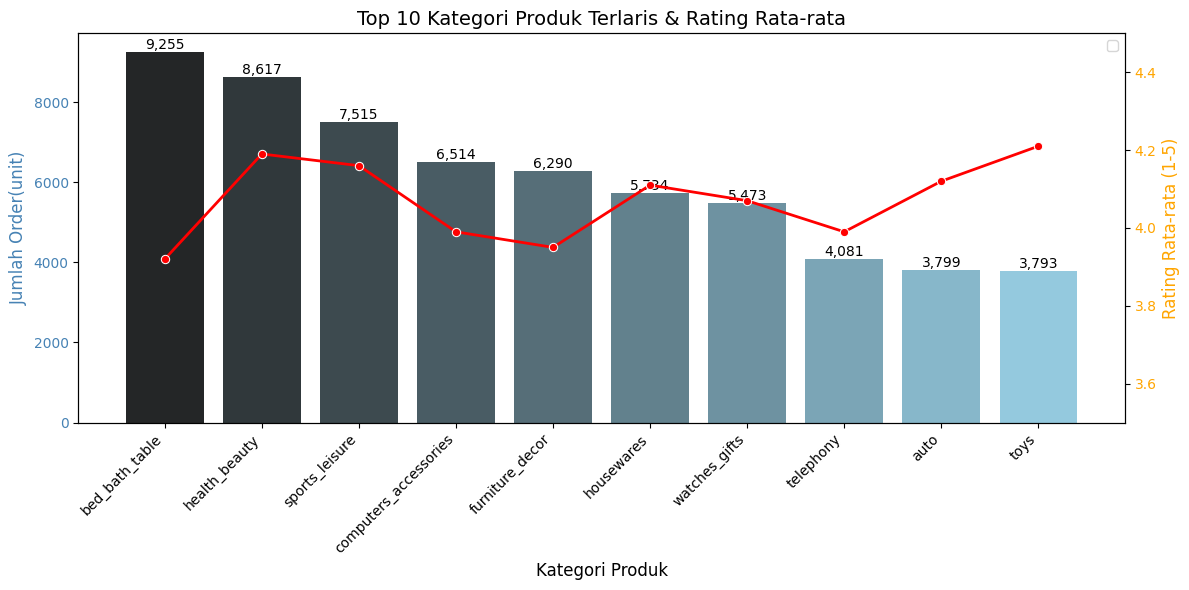

In [25]:
# Visualisasi kategori produk terlaris dengan review score rata-rata tertinggi
top_categories = product_performance_df.head(10).copy()
fig, ax1 = plt.subplots(figsize=(12, 6))
bars = sns.barplot(x='product_category', y='total_orders', data=top_categories, ax=ax1, color='skyblue', hue='product_category', legend=False)
ax1.set_xlabel('Kategori Produk', fontsize=12)
ax1.set_ylabel('Jumlah Order(unit)', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Memberikan label nilai di atas setiap bar
for bar in bars.patches:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom',
        fontsize=10
    )
    
# Rata-rata review score
ax2 = ax1.twinx()
sns.lineplot(x=range(len(top_categories)), y='average_review_score', data=top_categories, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Rating Rata-rata (1-5)', color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_ylim(3.5, 4.5)
ax2.legend(loc='upper right', fontsize=10)

plt.title('Top 10 Kategori Produk Terlaris & Rating Rata-rata', fontsize=14)
plt.tight_layout()
plt.show()



### Analisis Lanjutan dari Pertanyaan 1
**Gap antara Popularitas vs Kepuasan Pelanggan** — Kategori mana yang sangat populer tapi ratingnya rendah atau sebaliknya? 

Kategori dengan GAP terbesar (populer tapi rating rendah):
                         product_category  total_orders  average_review_score  \
70              fashion_childrens_clothes             7                  5.00   
69                      cds_dvds_musicals            12                  4.64   
63                                flowers            29                  4.42   
58                         books_imported            50                  4.51   
65                          fashion_sport            25                  4.32   
55  small_appliances_home_oven_and_coffee            72                  4.44   
52                costruction_tools_tools            97                  4.44   
56                             cine_photo            63                  4.29   
53                      furniture_bedroom            90                  4.25   
60                                  music            38                  4.21   

    gap_score  
70       70.0  
69       68.0  
6

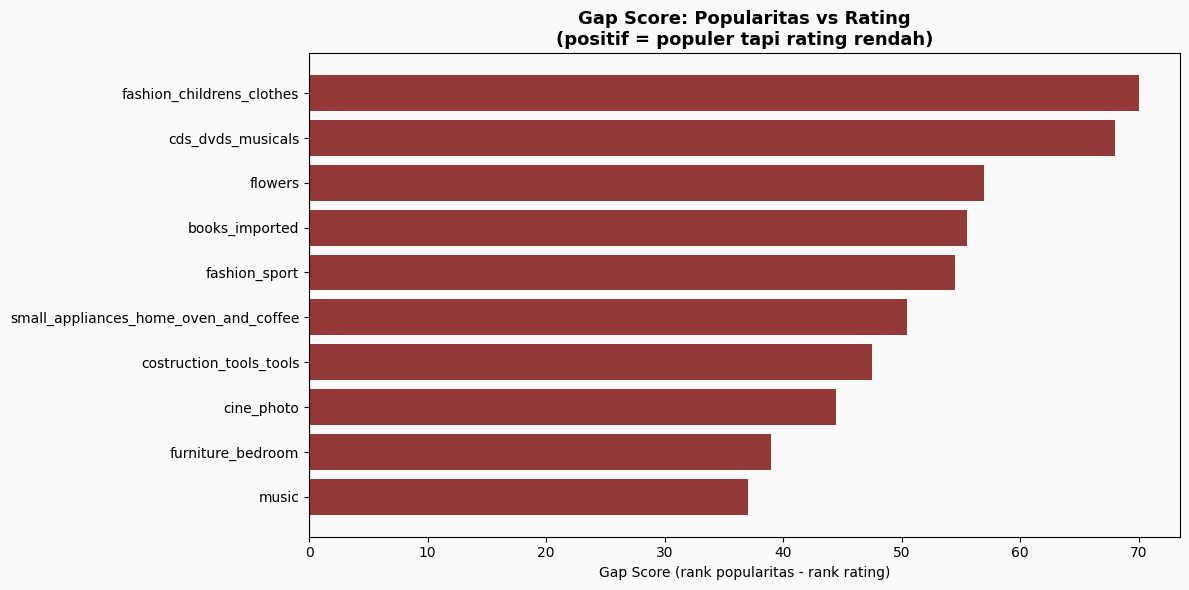


Kategori dengan gap terbesar: 'fashion_childrens_clothes'
  Total orders  : 7
  Avg rating    : 5.00
  Gap score     : 70.0


In [26]:
# Hitung rank popularitas dan rank rating
product_performance_df['rank_orders'] = product_performance_df['total_orders'].rank(ascending=False)
product_performance_df['rank_rating'] = product_performance_df['average_review_score'].rank(ascending=False)
product_performance_df['gap_score']   = product_performance_df['rank_orders'] - product_performance_df['rank_rating']

print('Kategori dengan GAP terbesar (populer tapi rating rendah):')
print(product_performance_df[['product_category','total_orders','average_review_score','gap_score']]
      .sort_values('gap_score', ascending=False).head(10))

# Visualisasi gap
top10_gap = product_performance_df.sort_values('gap_score', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

colors_gap = ["#943838" if g > 0 else '#1B5E20' for g in top10_gap['gap_score']]
ax.barh(top10_gap['product_category'][::-1], top10_gap['gap_score'][::-1], color=colors_gap[::-1])
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Gap Score: Popularitas vs Rating\n(positif = populer tapi rating rendah)', fontsize=13, fontweight='bold')
ax.set_xlabel('Gap Score (rank popularitas - rank rating)')
plt.tight_layout()
plt.show()

top_gap_cat = top10_gap.iloc[0]
print(f"\nKategori dengan gap terbesar: '{top_gap_cat['product_category']}'")
print(f"  Total orders  : {top_gap_cat['total_orders']:,}")
print(f"  Avg rating    : {top_gap_cat['average_review_score']:.2f}")
print(f"  Gap score     : {top_gap_cat['gap_score']:.1f}")

### Pertanyaan 2: Puncak Penjualan 6-12 Bulan Terakhir

**Tujuan Visualisasi:** Menampilkan tren penjualan 12 bulan terakhir dengan menyoroti bulan puncak menggunakan anotasi dan scatter highlight. Area fill digunakan untuk mempertegas volume kumulatif dan memudahkan pembaca melihat perubahan tren secara intuitif.


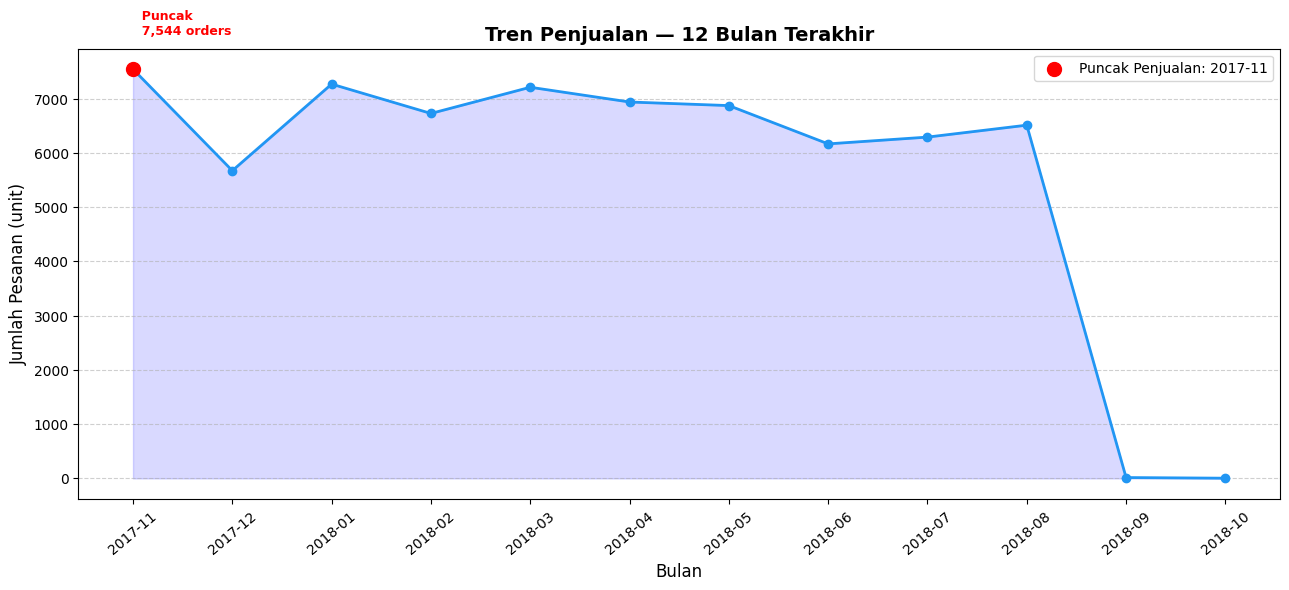

In [44]:
# Ambil 12 bulan data terakhir
last_12_months = monthly_orders.tail(12).copy()
last_12_months['year_month_str'] = last_12_months['year_month'].astype(str)

# Tandai bulan puncak
peak_idx = last_12_months['orders_count'].idxmax()

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(
    last_12_months['year_month_str'], last_12_months['orders_count'], marker='o', color='#2196F3', linewidth=2, markersize=6
)

# Highlight puncak
peak_row = last_12_months.loc[peak_idx]
ax.scatter(peak_row['year_month_str'], peak_row['orders_count'], color='red', s=100, zorder=5, label=f'Puncak Penjualan: {peak_row["year_month_str"]}')
ax.annotate(
    f'  Puncak\n  {peak_row["orders_count"]:,} orders',
    xy=(peak_row['year_month_str'], peak_row['orders_count']),
    xytext=(0, 25), textcoords='offset points',
    fontsize=9, color='red', fontweight='bold'
)

ax.fill_between(last_12_months['year_month_str'], last_12_months['orders_count'], alpha=0.15, color='blue')

ax.set_title('Tren Penjualan — 12 Bulan Terakhir', fontsize=14, fontweight='bold')
ax.set_xlabel('Bulan', fontsize=12)
ax.set_ylabel('Jumlah Pesanan (unit)', fontsize=12)
ax.tick_params(axis='x', rotation=40)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Analisis Lanjutan dari Pertanyaan 2 
**Membahas apakah lonjakan November berulang dan kategori apa yang mendorong puncak tersebut** dimana hal ini menyangkut pola musiman dan kategori pendorong puncak

Data semua bulan November dalam dataset:
year_month_str  orders_count
       2017-11          7544

Top 5 kategori pendorong penjualan di bulan puncak (2017-11):
product_category  total_orders
  bed_bath_table           803
  sports_leisure           541
 furniture_decor           536
   health_beauty           514
            toys           443


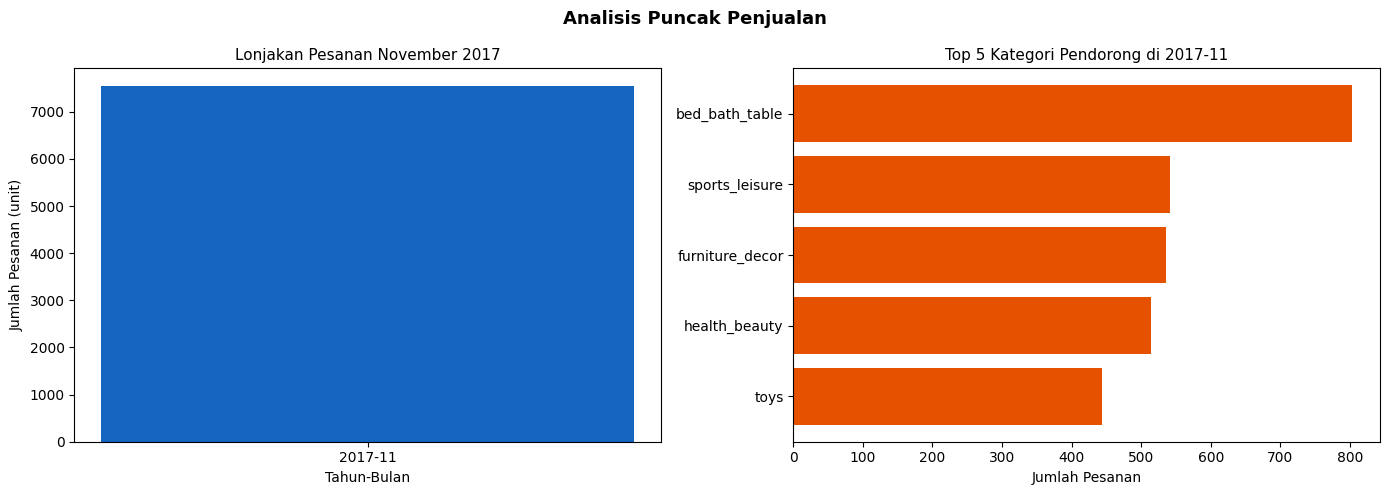

In [48]:
# Tambah kolom year_month_str ke master_df jika belum ada
master_df['year_month_str'] = master_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Cek apakah pola November berulang
monthly_orders['bulan'] = monthly_orders['year_month'].apply(lambda x: x.month)
november_data = monthly_orders[monthly_orders['bulan'] == 11]
print('Data semua bulan November dalam dataset:')
print(november_data[['year_month_str', 'orders_count']].to_string(index=False))

# Kategori pendorong di bulan puncak
peak_month_str = peak_month['year_month_str']
peak_category = (
    master_df[master_df['year_month_str'] == peak_month_str]
    .groupby('product_category')
    .agg(total_orders=('order_id', 'nunique'))
    .sort_values('total_orders', ascending=False)
    .head(5)
    .reset_index()
)
print(f'\nTop 5 kategori pendorong penjualan di bulan puncak ({peak_month_str}):')
print(peak_category.to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Puncak Penjualan', fontsize=13, fontweight='bold')

axes[0].bar(november_data['year_month_str'], november_data['orders_count'], color='#1565C0')
axes[0].set_title('Lonjakan Pesanan November 2017', fontsize=11)
axes[0].set_xlabel('Tahun-Bulan')
axes[0].set_ylabel('Jumlah Pesanan (unit)')

axes[1].barh(peak_category['product_category'][::-1], peak_category['total_orders'][::-1], color='#E65100')
axes[1].set_title(f'Top 5 Kategori Pendorong di {peak_month_str}', fontsize=11)
axes[1].set_xlabel('Jumlah Pesanan')

plt.tight_layout()
plt.show()

* Catatan: Dataset hanya memiliki 1 bulan November (2017) karena dataset berakhir Oktober 2018, sehingga pola musiman berulang tidak dapat dibuktikan dari data ini. Lonjakan ini diduga terkait event Black Friday dan musim liburan akhir tahun.

### Pertanyaan 3: Waktu Puncak Transaksi (Hari & Jam)

**Tujuan Visualisasi:** Mengidentifikasi window waktu optimal untuk kampanye pemasaran (push notification, flash sale, email blast).
* Bar chart digunakan untuk distribusi per hari (kategorikal), sementara line chart digunakan untuk distribusi per jam karena jam bersifat kontinu dan menunjukkan pola kurva yang jelas.

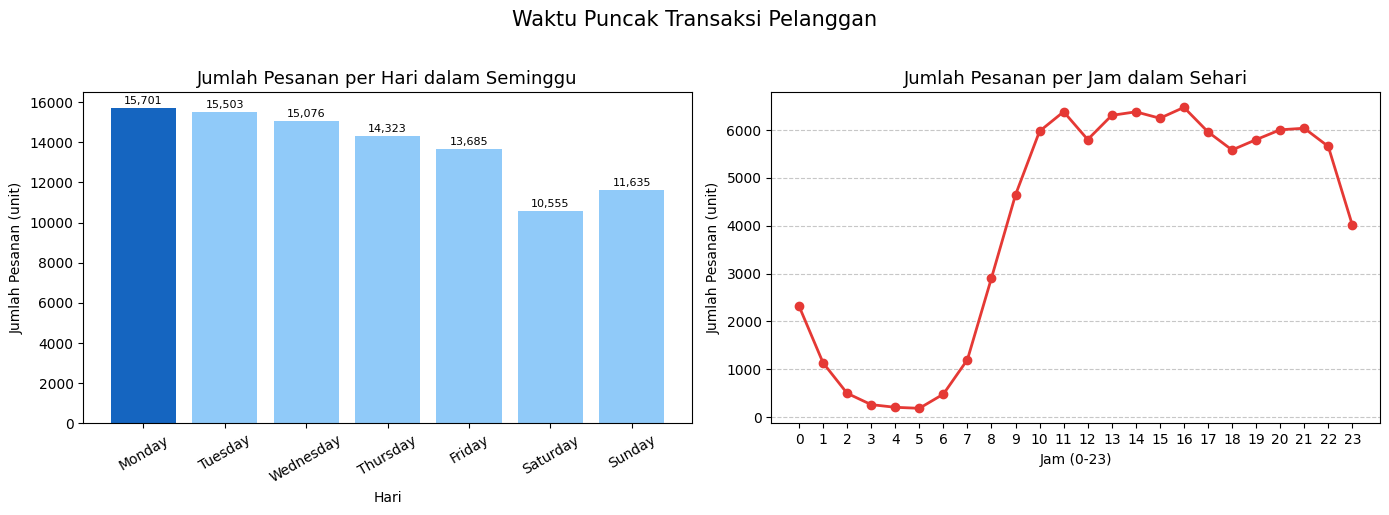

In [29]:
# Waktu puncak transaksi dalam (hari dan jam)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
peak_day_sorted = delivered_orders['order_day_of_week'].value_counts().reindex(day_order)
peak_hour_data = delivered_orders['order_hour'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
peak_day_name = peak_day_sorted.idxmax()
# Bar chart hari
colors_day = ['#1565C0' if d == peak_day_name else '#90CAF9' for d in peak_day_sorted.index]
bars_day = axes[0].bar(peak_day_sorted.index, peak_day_sorted.values, color=colors_day)
for bar in bars_day:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=8
    )
axes[0].set_title('Jumlah Pesanan per Hari dalam Seminggu', fontsize=13)
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Jumlah Pesanan (unit)')
axes[0].tick_params(axis='x', rotation=30)

# Line chart jam
axes[1].plot(peak_hour_data.index, peak_hour_data.values, marker='o', color='#E53935', linewidth=2)
axes[1].set_title('Jumlah Pesanan per Jam dalam Sehari', fontsize=13)
axes[1].set_xlabel('Jam (0-23)')
axes[1].set_ylabel('Jumlah Pesanan (unit)')
axes[1].set_xticks(range(0, 24))
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Waktu Puncak Transaksi Pelanggan', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Senin** adalah hari tersibuk. Jam puncak berada di **10:00–16:00** (jam kerja/istirahat makan siang). Ini adalah window optimal untuk push notification, email blast, dan flash sale.

### Analisis Lanjutan dari Pertanyaan 3
**Membahas mengenai pola jam transaksi SP berbeda dengan state lainnya**

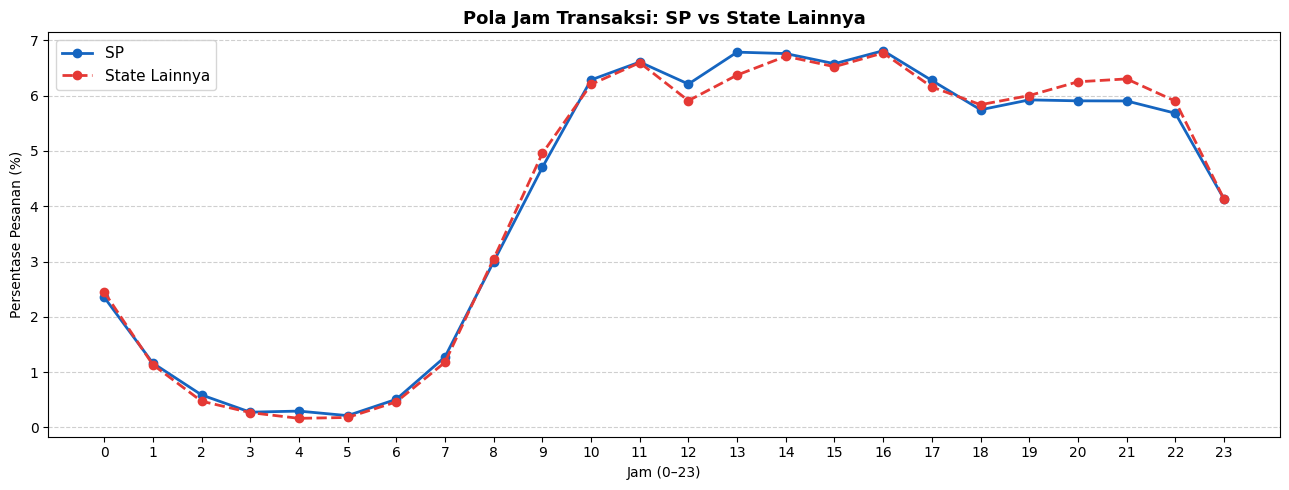

Jam puncak SP            : 16:00 (6.8%)
Jam puncak State Lainnya : 16:00 (6.8%)


In [30]:
sp_orders    = master_df[master_df['customer_state'] == 'SP']
nonsp_orders = master_df[master_df['customer_state'] != 'SP']

sp_hour    = sp_orders['order_hour'].value_counts().sort_index()
nonsp_hour = nonsp_orders['order_hour'].value_counts().sort_index()

# Normalisasi ke persentase agar bisa dibandingkan
sp_hour_pct    = sp_hour / sp_hour.sum() * 100
nonsp_hour_pct = nonsp_hour / nonsp_hour.sum() * 100

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sp_hour_pct.index, sp_hour_pct.values,
        marker='o', label='SP', color='#1565C0', linewidth=2)
ax.plot(nonsp_hour_pct.index, nonsp_hour_pct.values,
        marker='o', label='State Lainnya', color='#E53935', linewidth=2, linestyle='--')
ax.set_title('Pola Jam Transaksi: SP vs State Lainnya', fontsize=13, fontweight='bold')
ax.set_xlabel('Jam (0–23)')
ax.set_ylabel('Persentase Pesanan (%)')
ax.set_xticks(range(0, 24))
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Jam puncak SP            : {sp_hour.idxmax()}:00 ({sp_hour_pct[sp_hour.idxmax()]:.1f}%)')
print(f'Jam puncak State Lainnya : {nonsp_hour.idxmax()}:00 ({nonsp_hour_pct[nonsp_hour.idxmax()]:.1f}%)')

### Pertanyaan 4: Tren Pesanan Bulanan secara Keseluruhan
**Tujuan Visualisasi:** Menampilkan gambaran besar tren pertumbuhan e-commerce dari awal dataset (2016) hingga akhir (2018). 

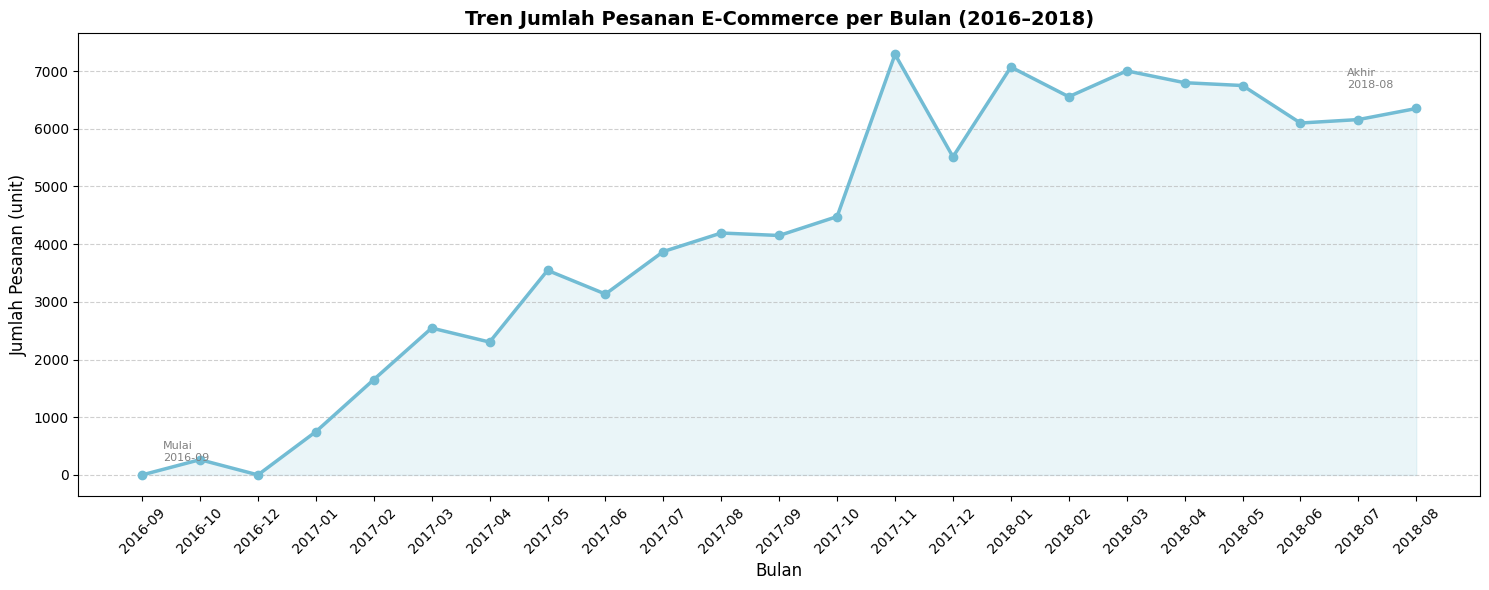

In [31]:
# Tren lengkap semua periode
all_monthly = (
    delivered_orders
    .groupby('year_month')
    .size()
    .reset_index(name='order_count')
)
all_monthly['year_month_str'] = all_monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(all_monthly['year_month_str'], all_monthly['order_count'],
        marker='o', color='#72BCD4', linewidth=2.5, markersize=6)
ax.fill_between(all_monthly['year_month_str'], all_monthly['order_count'],
                alpha=0.15, color='#72BCD4')

# Anotasi awal & akhir
ax.annotate(f'Mulai\n{all_monthly.iloc[0]["year_month_str"]}',
            xy=(all_monthly.iloc[0]['year_month_str'], all_monthly.iloc[0]['order_count']),
            xytext=(15, 10), textcoords='offset points', fontsize=8, color='gray')
ax.annotate(f'Akhir\n{all_monthly.iloc[-1]["year_month_str"]}',
            xy=(all_monthly.iloc[-1]['year_month_str'], all_monthly.iloc[-1]['order_count']),
            xytext=(-50, 15), textcoords='offset points', fontsize=8, color='gray')

ax.set_title('Tren Jumlah Pesanan E-Commerce per Bulan (2016–2018)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Bulan', fontsize=12)
ax.set_ylabel('Jumlah Pesanan (unit)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Tren menunjukkan **pertumbuhan konsisten dan positif** dari 2017 hingga 2018, mencerminkan adopsi e-commerce yang semakin masif di Brazil.

### Analisis Lanjutan dari Pertanyaan 4
**Menjawab pertanyaan :** Kategori mana yang paling banyak mendorong pertumbuhan pesanan bulanan?

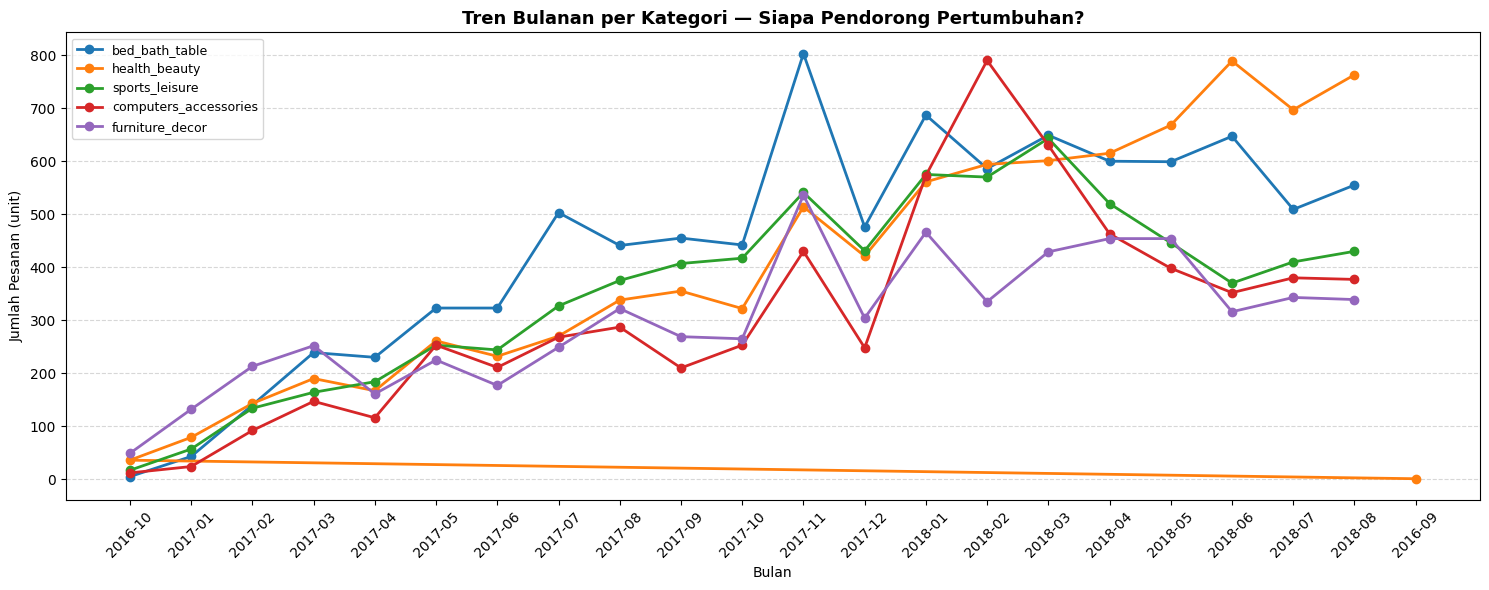

Top 5 kategori yang dianalisis:
  - bed_bath_table
  - health_beauty
  - sports_leisure
  - computers_accessories
  - furniture_decor


In [32]:
# Tren bulanan dipecah per top 5 kategori

top5_categories = (
    master_df.groupby('product_category')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

category_monthly = (
    master_df[master_df['product_category'].isin(top5_categories)]
    .groupby(['year_month', 'product_category'])
    .agg(total_orders=('order_id', 'nunique'))
    .reset_index()
)
category_monthly['year_month_str'] = category_monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(15, 6))
for cat in top5_categories:
    data = category_monthly[category_monthly['product_category'] == cat]
    ax.plot(data['year_month_str'], data['total_orders'], marker='o', linewidth=2, label=cat)

ax.set_title('Tren Bulanan per Kategori — Siapa Pendorong Pertumbuhan?', fontsize=13, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Pesanan (unit)')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Top 5 kategori yang dianalisis:')
for cat in top5_categories:
    print(f'  - {cat}')

### Pertanyaan 5: Distribusi Market Pelanggan per State

**Tujuan Visualisasi:** Memetakan dominasi market secara multidimensi menggunakan tiga visualisasi komplementer:
- **Bar horizontal** → ranking kuantitatif jumlah pelanggan
- **Bar horizontal revenue** → konfirmasi korelasi antara jumlah pelanggan dan revenue
- **Donut chart** → proporsi market share secara visual intuitif

Penggunaan highlight warna pada SP bertujuan menarik perhatian ke temuan utama tanpa distorsi data.

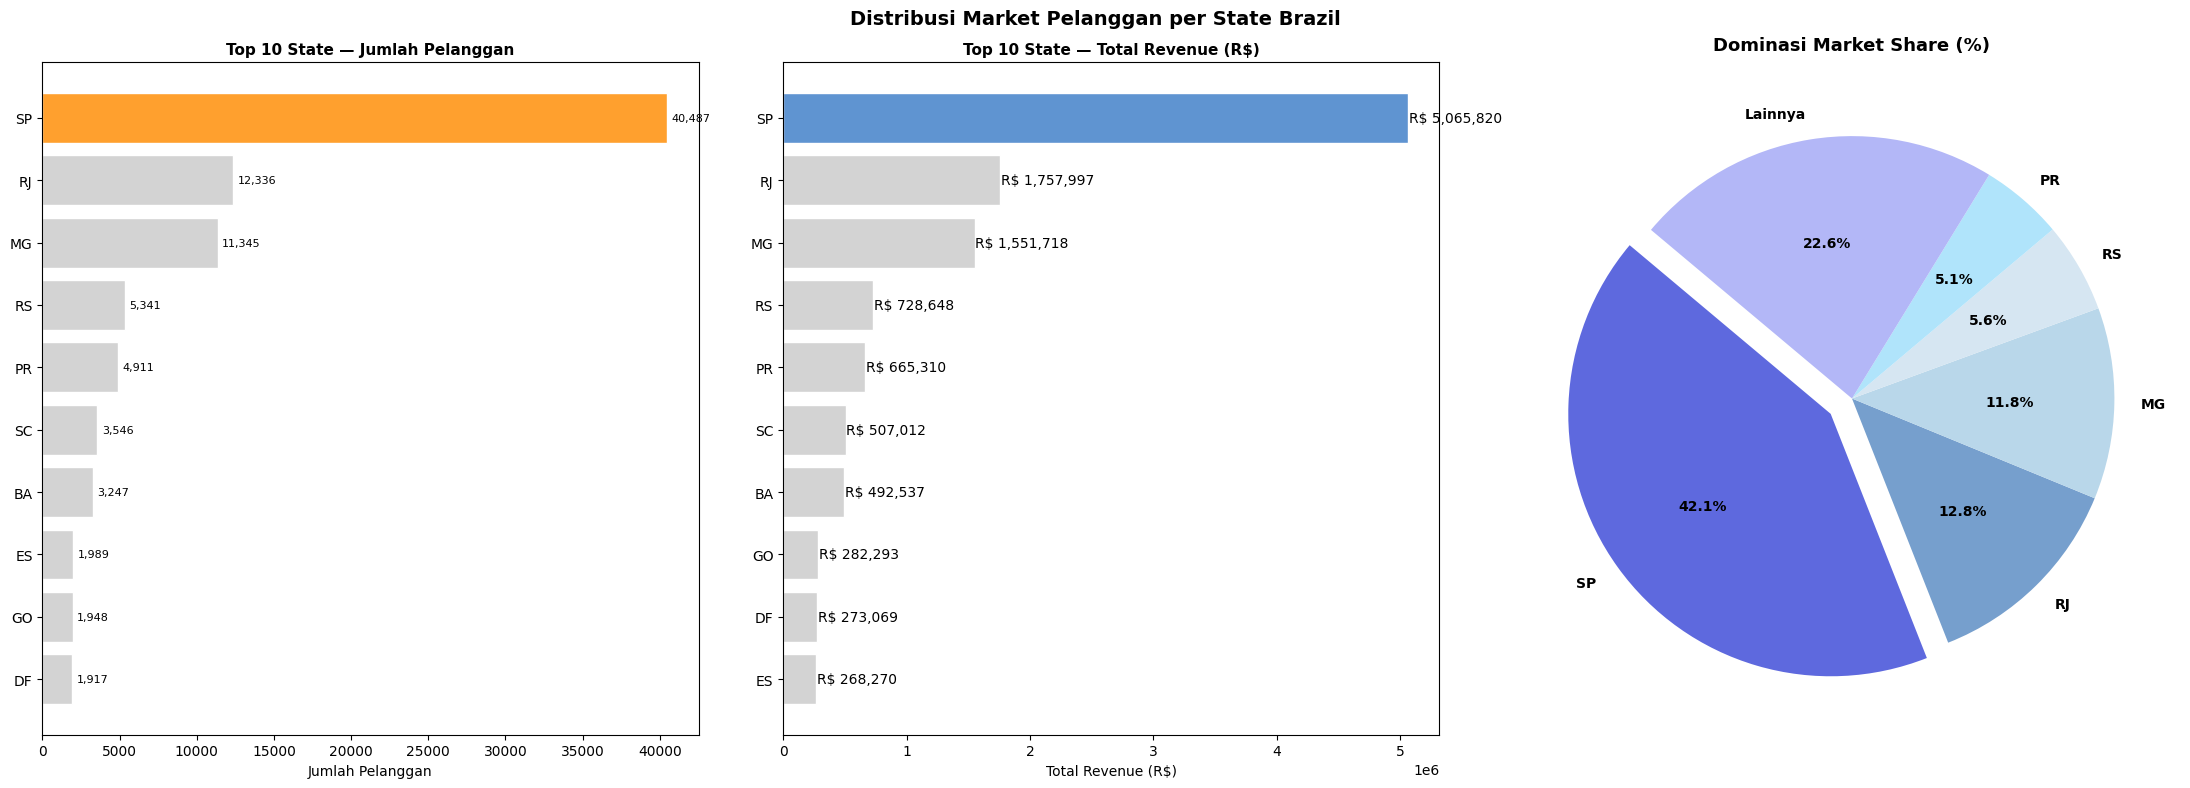

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Distribusi Market Pelanggan per State Brazil', fontsize=14, fontweight='bold')

# ── Kiri: Horizontal bar top 10 ─────────────────────
top10_state = state_market.head(10)
colors_bar  = ['#FFA02E' if i == 0 else '#D3D3D3' for i in range(len(top10_state))]
bars = axes[0].barh(top10_state['customer_state'][::-1],
                    top10_state['total_customers'][::-1],
                    color=colors_bar[::-1], edgecolor='white')
axes[0].set_title('Top 10 State — Jumlah Pelanggan', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Jumlah Pelanggan')

# Label angka
for bar in bars:
    axes[0].text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}', va='center', fontsize=8)

# ── Tengah: Horizontal bar revenue ──────────────────
top10_rev = state_market.sort_values('total_revenue', ascending=False).head(10)
colors_bar2 = ["#5F94D1" if i == 0 else "#D3D3D3" for i in range(len(top10_rev))]
bars_rev = axes[1].barh(top10_rev['customer_state'][::-1],
                        top10_rev['total_revenue'][::-1],
                        color=colors_bar2[::-1], edgecolor='white')
for bar in bars_rev:
    axes[1].text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
                 f'R$ {int(bar.get_width()):,}', va='center', fontsize=10)

axes[1].set_title('Top 10 State — Total Revenue (R$)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Total Revenue (R$)')

# ── Kanan: Pie chart market share ───────────────────
top5     = state_market.head(5).copy()
others   = state_market.iloc[5:]['total_customers'].sum()
pie_data = pd.concat([top5[['customer_state','total_customers']], 
                      pd.DataFrame([{'customer_state': 'Lainnya', 'total_customers': others}])], 
                     ignore_index=True)

colors_pie = ["#5E69DE", '#769FCD', '#B9D7EA', '#D6E6F2', "#B0E4FB", "#B3B7F7"]
explode = [0.1 if i == 0 else 0 for i in range(len(pie_data))] # Beri jarak untuk state SP

axes[2].pie(
    pie_data['total_customers'], 
    labels=pie_data['customer_state'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_pie,
    explode=explode,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
axes[2].set_title('Dominasi Market Share (%)', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

* **SP** memimpin dengan 42.1% market share dan revenue sejumlah R$ 5,06 juta, jauh meninggalkan semua state lain 
* **RJ** dengan 12.8% — posisi ke-2 tapi hanya sepertiga SP. Sudah ada basis pelanggan kuat (Mature)
* **SC, BA** - Muncul di bar chart (3.546 & 3.247 pelanggan) sekaligus masuk tabel ekspansi (Tqumbuh)


### Analisis Lanjutan dari Pertanyaan 5
Melakukan identifikasi state potensial untuk melakukan ekspansi di luar SP, RJ dan MG

Top 10 State Potensial untuk Ekspansi (di luar SP/RJ/MG):
customer_state  orders_first  orders_second  growth_pct
            DF           384           1533       299.2
            MS           147            554       276.9
            AP            15             52       246.7
            PE           363           1226       237.7
            MT           204            680       233.3
            GO           456           1492       227.2
            BA           769           2478       222.2
            ES           478           1511       216.1
            SC           855           2691       214.7
            RN           115            357       210.4


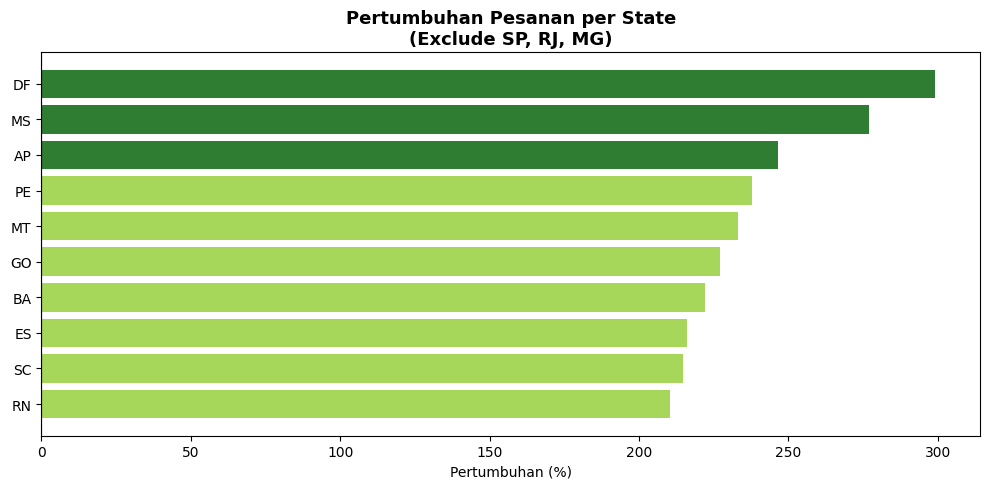

In [34]:
all_periods = sorted(master_df['year_month_str'].unique())
mid_point   = all_periods[len(all_periods) // 2]

first_half  = master_df[master_df['year_month_str'] <  mid_point]
second_half = master_df[master_df['year_month_str'] >= mid_point]

orders_first  = first_half.groupby('customer_state')['order_id'].nunique().rename('orders_first')
orders_second = second_half.groupby('customer_state')['order_id'].nunique().rename('orders_second')

growth_df = pd.concat([orders_first, orders_second], axis=1).fillna(0)
growth_df['growth_pct'] = (
    (growth_df['orders_second'] - growth_df['orders_first'])
    / growth_df['orders_first'].replace(0, np.nan) * 100
).round(1)

# Exclude state dominan
expansion_targets = (
    growth_df[~growth_df.index.isin(['SP', 'RJ', 'MG'])]
    .sort_values('growth_pct', ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'index': 'customer_state'})
)

print('Top 10 State Potensial untuk Ekspansi (di luar SP/RJ/MG):')
print(expansion_targets[['customer_state', 'orders_first', 'orders_second', 'growth_pct']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors_exp = ["#2E7D32" if g < 3 else '#A7D75A' for g in range(len(expansion_targets))]

ax.barh(expansion_targets['customer_state'][::-1], expansion_targets['growth_pct'][::-1], color=colors_exp[::-1])

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Pertumbuhan Pesanan per State\n(Exclude SP, RJ, MG)', fontsize=13, fontweight='bold')
ax.set_xlabel('Pertumbuhan (%)')
plt.tight_layout()
plt.show()


In [35]:
# 1. Inisialisasi peta Brazil
brazil_map = folium.Map(location=[-14.2350, -51.9253], zoom_start=4)

# 2. Siapkan data (ambil 50.000 sampel agar ringan)
heat_data = master_df[['geolocation_lat', 'geolocation_lng']].sample(n=50000, random_state=42).values.tolist()

# 3. Tambahkan Heatmap ke peta
HeatMap(heat_data, radius=15, blur=10).add_to(brazil_map)

# --- SOLUSI AGAR MUNCUL DI VS CODE TANPA ERROR ---
# Kita simpan ke variabel HTML dan bungkus dengan IFrame
html_map = brazil_map._repr_html_()
iframe = branca.element.IFrame(html=html_map, width=800, height=500)

# Tampilkan peta
brazil_map.save('brazil_heatmap.html')

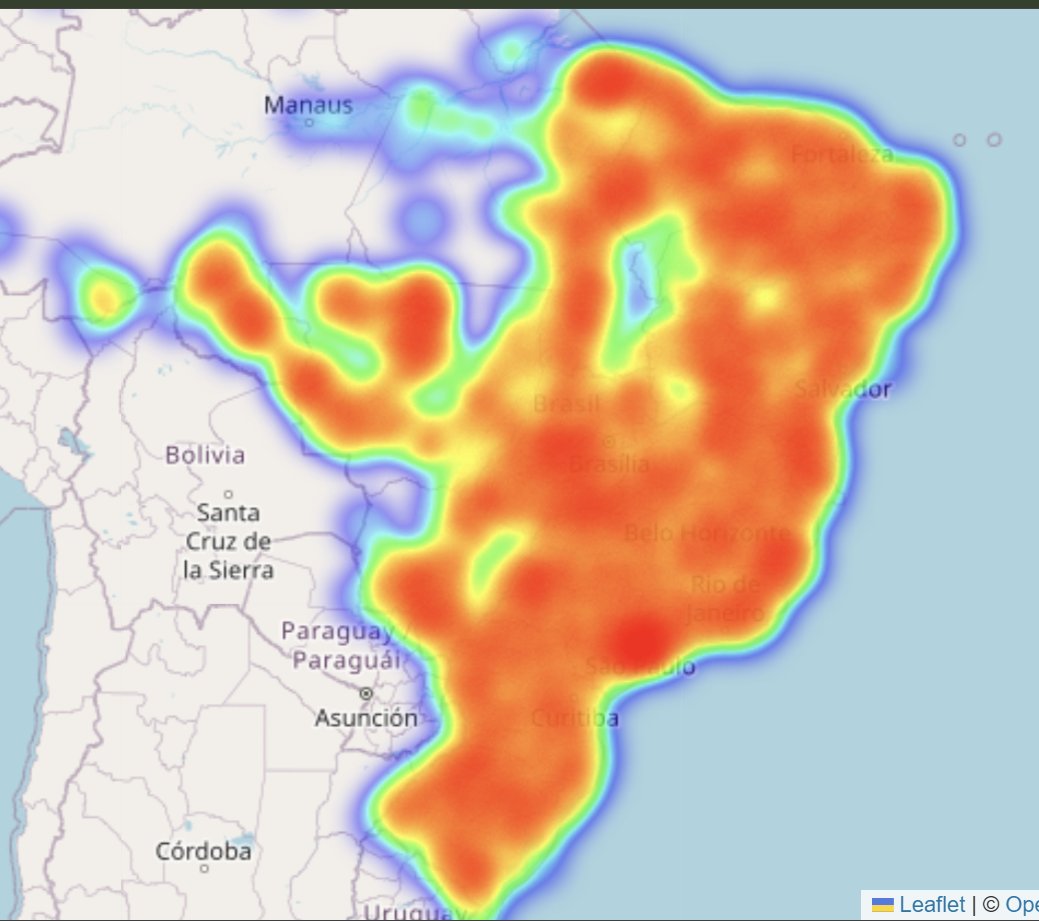

Berdasarkan peta heatmap di atas, terlihat bahwa konsentrasi pelanggan terbesar berada di wilayah Tenggara (Southeast) Brazil. Titik terpadat ditemukan di negara bagian São Paulo (SP), disusul oleh Rio de Janeiro (RJ) dan Minas Gerais (MG). Hal ini menjawab pertanyaan bisnis nomor 5, di mana strategi pemasaran sebaiknya difokuskan pada wilayah-wilayah dengan kepadatan pelanggan tinggi ini. Serta mengungkap kesenjangan yang tidak terlihat dari angka, yang mana  wilayah Northeast seperti BA dan PE mulai menguat secara organik di peta, sementara wilayah North seperti sekitar Manaus hampir kosong meski AP menunjukkan growth 246% — karena memang infrastrukturnya terbatas, jadi growth-nya tidak bisa diandalkan untuk ekspansi skala besar.

- Konsentrasi tertinggi: Southeast (SP, RJ, MG) → prioritas utama
- Wilayah kosong: North & Northeast → peluang ekspansi
- Pola menunjukkan korelasi kuat antara kepadatan penduduk dan volume e-commerce


SC dan BA memiliki peluang ekspansi terkuat, dikarenakan muncul di chart (basis pelanggan ada), masuk tabel ekspansi(tumbuh>210%) dan terlihat di heatmap dengan warna yang mulai menguat

RS dan PR - jangan diabaikan tetapi berbeda strategi. Mereka besar di chart dan pekat di peta, namun tidak muncul di tabel ekspansi. Yang artinya pasar sudah ada tapi lagi tidak tumbuh cepat.



### Pertanyaan 6: Faktor yang Mempengaruhi Penjualan

**Tujuan Visualisasi:** Menyajikan dua perspektif analisis faktor penjualan:
- **Heatmap korelasi** (panel kiri) → menampilkan semua hubungan antar variabel sekaligus, memudahkan identifikasi pola korelasi positif/negatif.
- **Scatter plot review vs volume** (panel kanan) → memvisualisasikan hubungan antara kepuasan pelanggan dan volume penjualan, dengan dimensi ketiga (warna = harga rata-rata) untuk memperkaya informasi dalam satu grafik.


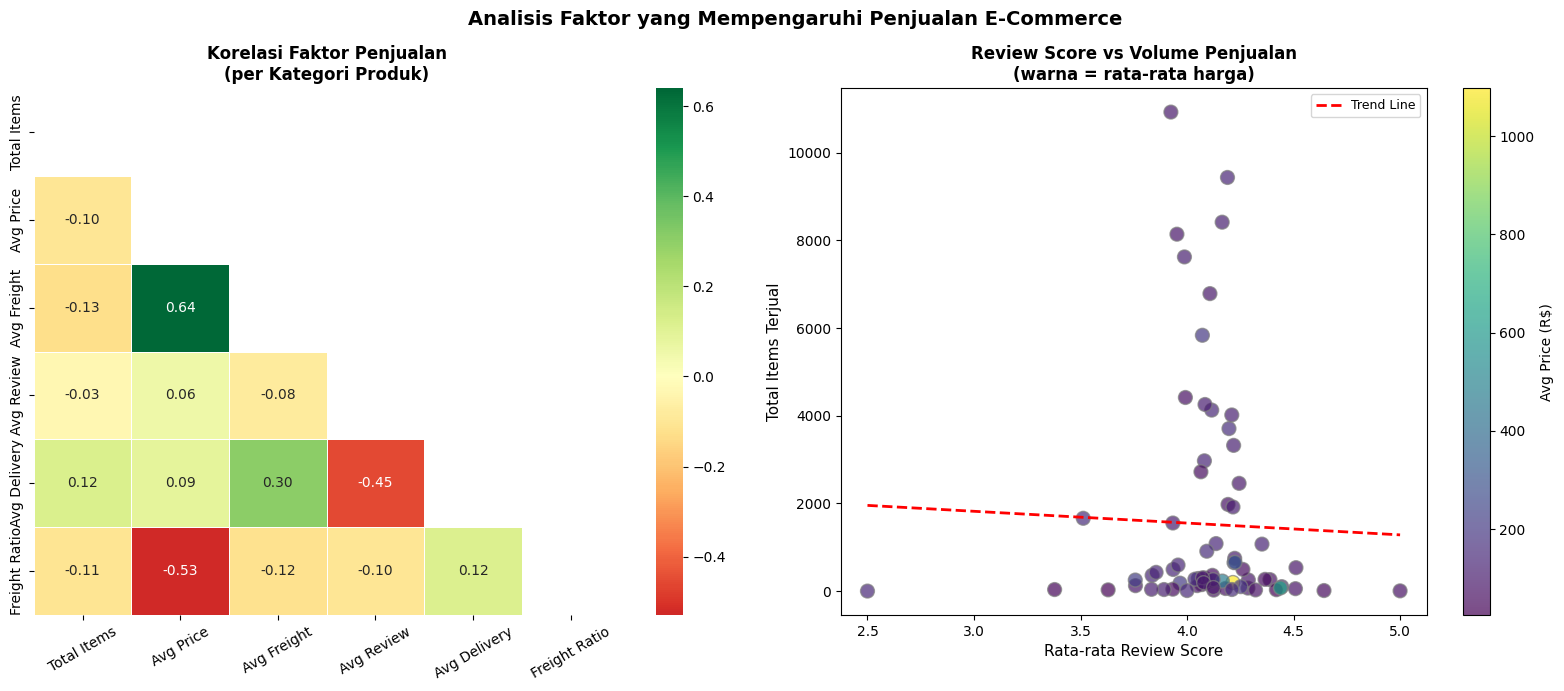

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Analisis Faktor yang Mempengaruhi Penjualan E-Commerce', fontsize=14, fontweight='bold')

# ── Kiri: Heatmap korelasi ───────────────────────────
mask   = np.triu(np.ones_like(corr_matrix, dtype=bool))
labels = ['Total Items','Avg Price','Avg Freight','Avg Review','Avg Delivery','Freight Ratio']
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[0], mask=mask, linewidths=0.5,
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Korelasi Faktor Penjualan\n(per Kategori Produk)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# ── Kanan: Scatter review vs volume ─────────────────
sc = axes[1].scatter(
    factor_df['avg_review_score'], factor_df['total_items'],
    c=factor_df['avg_price'], cmap='viridis', s=100, alpha=0.7, edgecolors='gray'
)
plt.colorbar(sc, ax=axes[1], label='Avg Price (R$)')

z = np.polyfit(factor_df['avg_review_score'].dropna(), factor_df['total_items'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(factor_df['avg_review_score'].min(), factor_df['avg_review_score'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend Line')
axes[1].set_xlabel('Rata-rata Review Score', fontsize=11)
axes[1].set_ylabel('Total Items Terjual', fontsize=11)
axes[1].set_title('Review Score vs Volume Penjualan\n(warna = rata-rata harga)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

- **Review Score** → korelasi positif (rating tinggi = lebih banyak terjual).  
- **Harga** → korelasi negatif (produk lebih murah terjual lebih banyak).  
- **Freight Ratio** tinggi → hambatan pembelian.  
- **Delivery time** panjang → korelasi negatif dengan penjualan.

### Analisis Lanjutan dari Pertanyaan 6
Menyangkut kategori mana yang paling terhambat ongkos kirim, dan mana yang harus diprioritaskan untuk subsidi

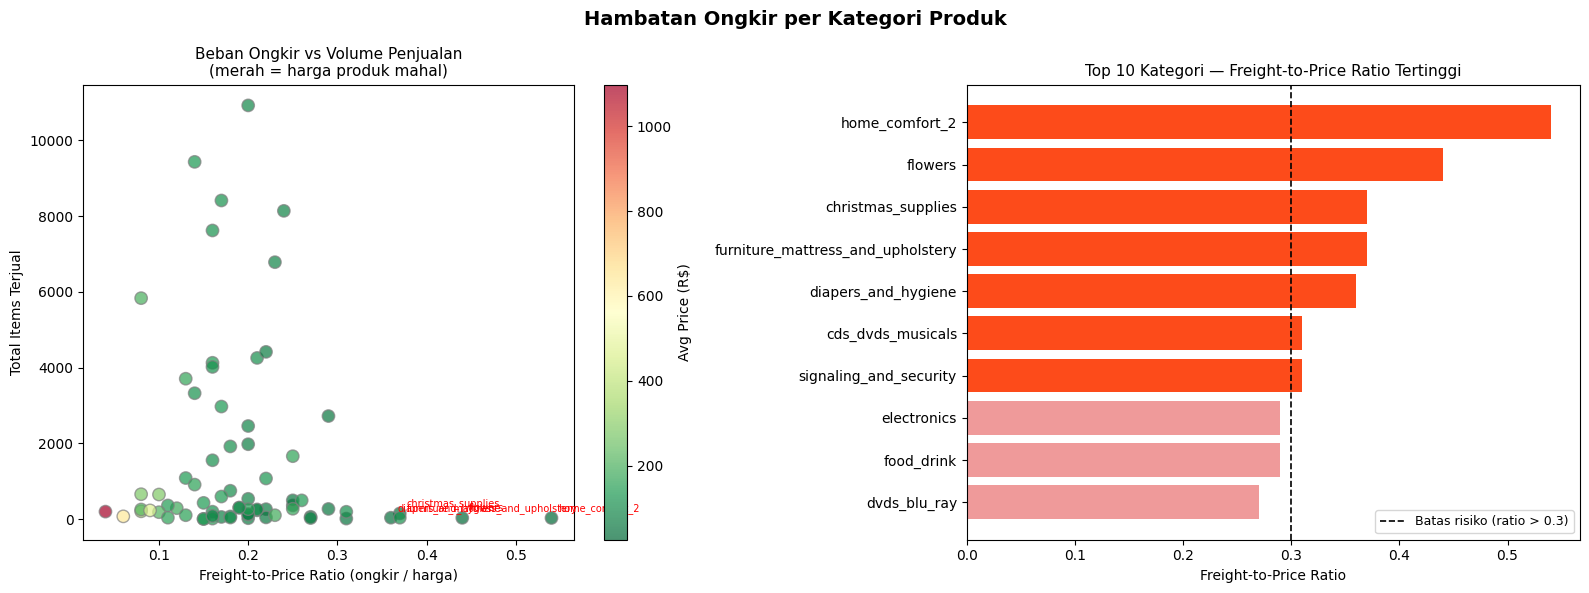


Kategori dengan freight ratio > 0.3 (prioritas subsidi ongkir):
                 product_category  freight_to_price_ratio  total_items  avg_price
                   home_comfort_2                    0.54           30  25.342333
                          flowers                    0.44           33  33.637576
               christmas_supplies                    0.37          150  58.252267
furniture_mattress_and_upholstery                    0.37           37 116.848108
              diapers_and_hygiene                    0.36           37  40.561892
                cds_dvds_musicals                    0.31           14  52.142857
           signaling_and_security                    0.31          194 107.217784


In [37]:
# Visualisasi hambatan ongkir per kategori
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hambatan Ongkir per Kategori Produk', fontsize=14, fontweight='bold')

# Kiri: Scatter freight ratio vs total items
sc = axes[0].scatter(
    factor_df['freight_to_price_ratio'],
    factor_df['total_items'],
    c=factor_df['avg_price'], cmap='RdYlGn_r',
    s=80, alpha=0.7, edgecolors='gray'
)
plt.colorbar(sc, ax=axes[0], label='Avg Price (R$)')

# Label 5 kategori dengan freight ratio tertinggi
high_ratio = factor_df.nlargest(5, 'freight_to_price_ratio')
for _, row in high_ratio.iterrows():
    axes[0].annotate(row['product_category'],
                     (row['freight_to_price_ratio'], row['total_items']),
                     fontsize=7, xytext=(5, 5), textcoords='offset points', color='red')

axes[0].set_xlabel('Freight-to-Price Ratio (ongkir / harga)')
axes[0].set_ylabel('Total Items Terjual')
axes[0].set_title('Beban Ongkir vs Volume Penjualan\n(merah = harga produk mahal)', fontsize=11)

# Kanan: Bar chart top 10 freight ratio
top_freight = factor_df.nlargest(10, 'freight_to_price_ratio')[['product_category','freight_to_price_ratio','total_items']]
colors_bar  = ["#FD4B1A" if r > 0.3 else '#EF9A9A' for r in top_freight['freight_to_price_ratio']]
axes[1].barh(top_freight['product_category'][::-1], top_freight['freight_to_price_ratio'][::-1], color=colors_bar[::-1])
axes[1].axvline(x=0.3, color='black', linestyle='--', linewidth=1.2, label='Batas risiko (ratio > 0.3)')
axes[1].set_title('Top 10 Kategori — Freight-to-Price Ratio Tertinggi', fontsize=11)
axes[1].set_xlabel('Freight-to-Price Ratio')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

risiko_tinggi = factor_df[factor_df['freight_to_price_ratio'] > 0.3][['product_category','freight_to_price_ratio','total_items','avg_price']].sort_values('freight_to_price_ratio', ascending=False)
print(f'\nKategori dengan freight ratio > 0.3 (prioritas subsidi ongkir):')
print(risiko_tinggi.to_string(index=False))

## Analisis Lanjutan (Opsional)

Analisis ini diperdalam dengan dua teknik segmentasi:
1. **RFM Analysis** — segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary value
2. **Clustering berbasis Binning** — pengelompokan perilaku belanja menggunakan kategorisasi kuantil

Tujuannya adalah menghasilkan rekomendasi yang lebih **personal dan terarah** bagi tim pemasaran.


## RFM Analysis: Segmentasi Pelanggan
**Teknik:** RFM (Recency-Frequency-Monetary) adalah metode segmentasi pelanggan yang mengukur tiga dimensi perilaku:
- **Recency** — Seberapa baru pelanggan bertransaksi? (lebih rendah = lebih baik)
- **Frequency** — Seberapa sering pelanggan bertransaksi?
- **Monetary** — Berapa total nilai pembelian pelanggan?

Setiap pelanggan diberi skor 1–5 untuk masing-masing dimensi menggunakan `pd.qcut`, kemudian dijumlahkan menjadi RFM Score (3–15). Skor tersebut digunakan untuk mengklasifikasikan pelanggan ke dalam 7 segmen: **Champions, Loyal Customers, Potential Loyalists, New Customers, Needs Attention, At Risk, Churned**.

In [38]:
# ── Bangun all_df dari tabel inti ──────────────────────
all_df = pd.merge(
    left=order_df[['order_id','customer_id','order_purchase_timestamp','order_status']],
    right=customers_df[['customer_id','customer_unique_id']],
    how='left', on='customer_id'
)
all_df = pd.merge(
    left=all_df,
    right=order_items_df[['order_id','price']],
    how='left', on='order_id'
)
all_df = all_df[all_df['order_status'] == 'delivered']

# Referensi tanggal: 1 hari setelah transaksi terakhir
now = all_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = all_df.groupby('customer_unique_id').agg(
    Recency  =('order_purchase_timestamp', lambda x: (now - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary =('price', 'sum')
).reset_index()
rfm_df.columns.name = None

print(f'Total pelanggan unik: {len(rfm_df):,}')
print('\nTop 5 pelanggan berdasarkan Monetary:')
print(rfm_df.sort_values('Monetary', ascending=False).head(5).to_string(index=False))

Total pelanggan unik: 93,358

Top 5 pelanggan berdasarkan Monetary:
              customer_unique_id  Recency  Frequency  Monetary
0a0a92112bd4c708ca5fde585afaa872      334          1   13440.0
da122df9eeddfedc1dc1f5349a1a690c      515          2    7388.0
763c8b1c9c68a0229c42c9fc6f662b93       46          1    7160.0
dc4802a71eae9be1dd28f5d788ceb526      563          1    6735.0
459bef486812aa25204be022145caa62       35          1    6729.0


In [39]:
# Scoring RFM (1-5)
rfm_df['R_score'] = pd.qcut(rfm_df['Recency'],
                             q=5, labels=[5,4,3,2,1]).astype(int)
rfm_df['F_score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'),
                             q=5, labels=[1,2,3,4,5]).astype(int)
rfm_df['M_score'] = pd.qcut(rfm_df['Monetary'],
                             q=5, labels=[1,2,3,4,5]).astype(int)
rfm_df['RFM_score'] = rfm_df['R_score'] + rfm_df['F_score'] + rfm_df['M_score']

def rfm_segment(row):
    if row['RFM_score'] >= 13:
        return 'Champions'
    elif row['RFM_score'] >= 10:
        return 'Loyal Customers'
    elif row['RFM_score'] >= 7:
        return 'Potential Loyalists'
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'New Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2:
        return 'Churned'
    else:
        return 'Needs Attention'

rfm_df['Segment'] = rfm_df.apply(rfm_segment, axis=1)

seg_summary = rfm_df.groupby('Segment').agg(
    count        =('customer_unique_id', 'count'),
    avg_recency  =('Recency', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_monetary =('Monetary', 'mean')
).round(2).reset_index()
seg_summary['pct'] = (seg_summary['count'] / seg_summary['count'].sum() * 100).round(1)

print('RFM Segmentation Summary:')
print(seg_summary.sort_values('count', ascending=False).to_string(index=False))

RFM Segmentation Summary:
            Segment  count  avg_recency  avg_frequency  avg_monetary  pct
Potential Loyalists  38521       263.98           1.01        109.14 41.3
    Loyal Customers  31260       175.03           1.04        188.56 33.5
            Churned   9277       407.81           1.00         59.75  9.9
          Champions   7894        93.41           1.20        298.46  8.5
            At Risk   3275       436.69           1.00         33.56  3.5
    Needs Attention   2354       219.13           1.00         35.15  2.5
      New Customers    777       137.71           1.00         25.90  0.8


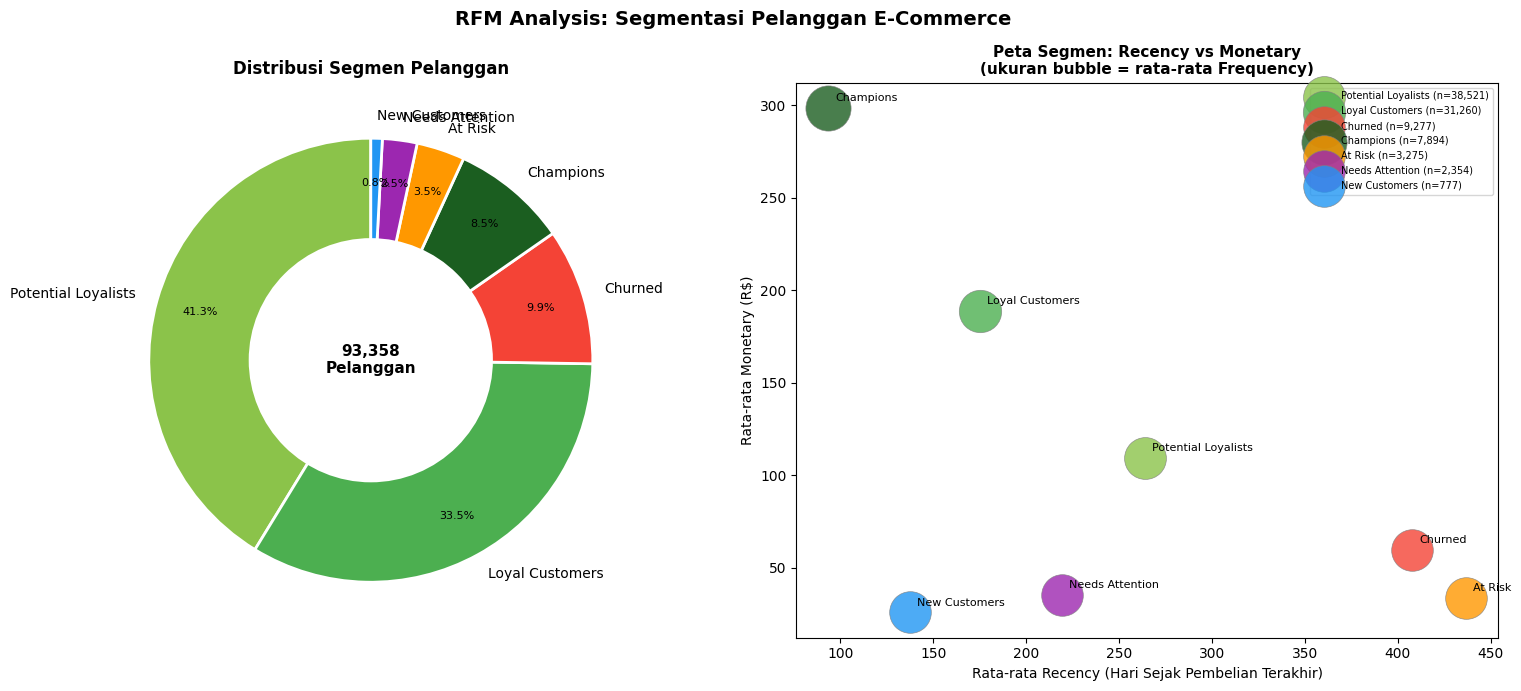

In [40]:
# Visualisasi RFM 
seg_colors = {
    'Champions'          : '#1B5E20',
    'Loyal Customers'    : '#4CAF50',
    'Potential Loyalists': '#8BC34A',
    'New Customers'      : '#2196F3',
    'At Risk'            : '#FF9800',
    'Churned'            : '#F44336',
    'Needs Attention'    : '#9C27B0'
}
seg_plot = seg_summary.sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('RFM Analysis: Segmentasi Pelanggan E-Commerce', fontsize=14, fontweight='bold')

# Donut chart
colors_list = [seg_colors.get(s, '#888') for s in seg_plot['Segment']]
wedges, texts, autotexts = axes[0].pie(
    seg_plot['count'], labels=seg_plot['Segment'],
    autopct='%1.1f%%', colors=colors_list,
    startangle=90, pctdistance=0.8,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
axes[0].add_artist(centre_circle)
axes[0].text(0, 0, f'{seg_plot["count"].sum():,}\nPelanggan',
             ha='center', va='center', fontsize=11, fontweight='bold')
for t in autotexts: t.set_fontsize(8)
axes[0].set_title('Distribusi Segmen Pelanggan', fontsize=12, fontweight='bold')

# Scatter: Recency vs Monetary
for _, row in seg_plot.iterrows():
    axes[1].scatter(row['avg_recency'], row['avg_monetary'],
                    s=row['avg_frequency']*800 + 100,
                    color=seg_colors.get(row['Segment'], '#888'),
                    alpha=0.8, edgecolors='gray', linewidth=0.5,
                    label=f"{row['Segment']} (n={row['count']:,})")
    axes[1].annotate(row['Segment'], (row['avg_recency'], row['avg_monetary']),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)

axes[1].set_xlabel('Rata-rata Recency (Hari Sejak Pembelian Terakhir)', fontsize=10)
axes[1].set_ylabel('Rata-rata Monetary (R$)', fontsize=10)
axes[1].set_title('Peta Segmen: Recency vs Monetary\n(ukuran bubble = rata-rata Frequency)',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

## Clustering : Segmentasi Perilaku Belanja

**Teknik:** Segmentasi berbasis binning manual menggunakan `pd.cut` (Recency) dan `pd.qcut` (Monetary) untuk membagi pelanggan ke dalam kelompok perilaku yang lebih granular. Pendekatan ini dipilih karena lebih interpretable dibanding K-Means untuk tujuan strategi pemasaran.

- **Champions** → pelanggan terbaik: baru belanja, sering, nilai tinggi. Berikan reward eksklusif.
- **At Risk** → aktif sebelumnya tapi mulai menghilang → retarget dengan kampanye win-back.
- **Churned** → lama tidak belanja → kampanye reaktivasi dengan diskon khusus.
- **Potential Loyalists** → potensial besar → program loyalitas untuk naik kelas.

In [41]:
# ── Binning Recency ────────────────────────────────────
rfm_df['recency_bin'] = pd.cut(
    rfm_df['Recency'],
    bins=[0, 30, 90, 180, np.inf],
    labels=['Fresh (0-30 hari)', 'Recent (31-90 hari)',
            'Moderate (91-180 hari)', 'Lama (>180 hari)']
)

# ── Binning Monetary ───────────────────────────────────
rfm_df['monetary_bin'] = pd.qcut(
    rfm_df['Monetary'], q=4,
    labels=['Low Spender', 'Mid Spender', 'High Spender', 'Premium Spender']
)

# ── Binning Frequency ──────────────────────────────────
rfm_df['frequency_bin'] = rfm_df['Frequency'].apply(
    lambda x: 'Single Purchase' if x == 1
              else ('Returning (2-3x)' if x <= 3 else 'Loyal (4x+)')
)

# Ringkasan cluster
cluster_summary = rfm_df.groupby(['recency_bin', 'monetary_bin']).agg(
    pelanggan=('customer_unique_id', 'count'),
    avg_freq =('Frequency', 'mean'),
    avg_spend=('Monetary', 'mean')
).round(2).reset_index()

print('Cluster Summary (Recency × Monetary):')
print(cluster_summary.to_string(index=False))

Cluster Summary (Recency × Monetary):
           recency_bin    monetary_bin  pelanggan  avg_freq  avg_spend
     Fresh (0-30 hari)     Low Spender       1726      1.01      29.54
     Fresh (0-30 hari)     Mid Spender       1784      1.01      65.28
     Fresh (0-30 hari)    High Spender       1643      1.03     118.31
     Fresh (0-30 hari) Premium Spender       1607      1.11     351.79
   Recent (31-90 hari)     Low Spender       2915      1.00      28.94
   Recent (31-90 hari)     Mid Spender       2780      1.02      65.78
   Recent (31-90 hari)    High Spender       3020      1.03     118.34
   Recent (31-90 hari) Premium Spender       2984      1.10     364.17
Moderate (91-180 hari)     Low Spender       4795      1.01      29.37
Moderate (91-180 hari)     Mid Spender       4738      1.02      65.91
Moderate (91-180 hari)    High Spender       5063      1.03     118.80
Moderate (91-180 hari) Premium Spender       5051      1.09     358.55
      Lama (>180 hari)     Low Spender 

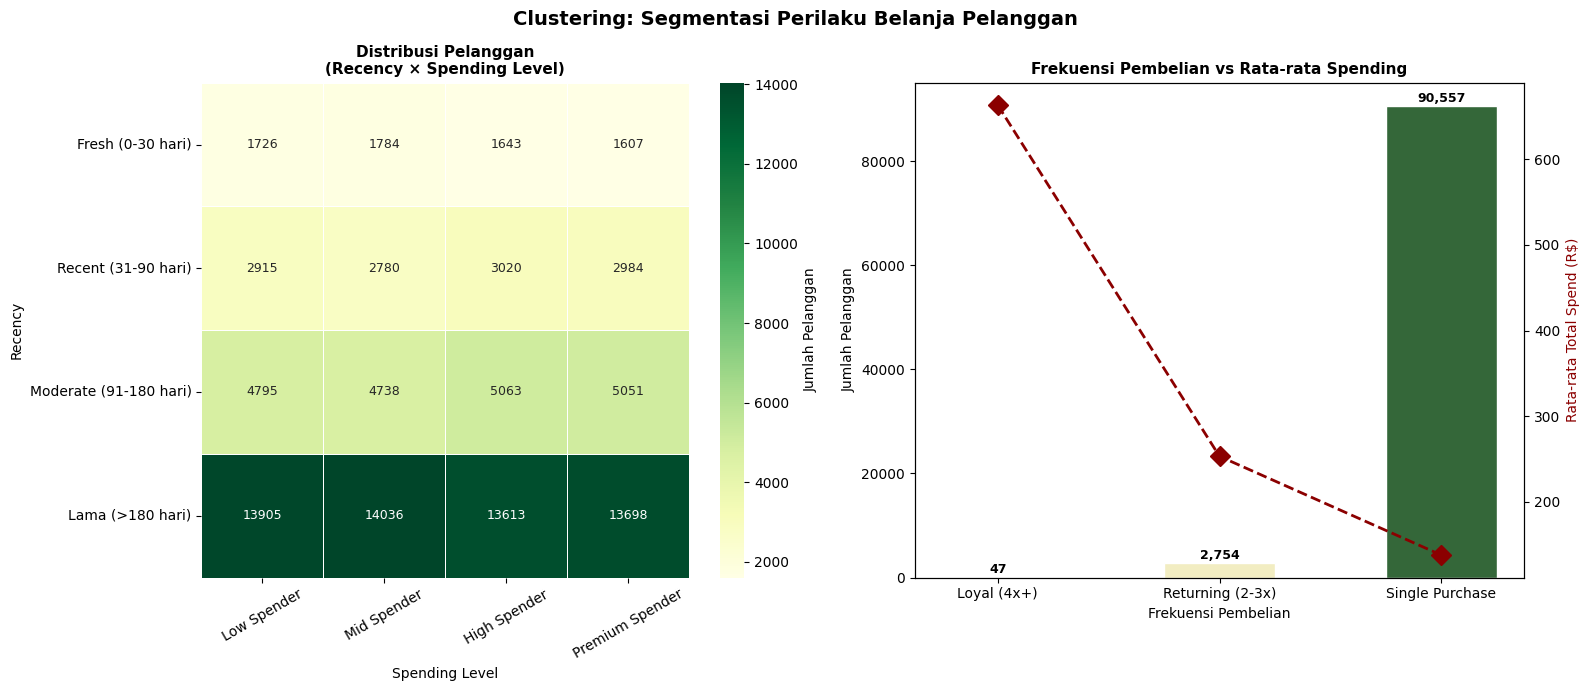

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Clustering: Segmentasi Perilaku Belanja Pelanggan', fontsize=14, fontweight='bold')

# ── Heatmap ────────────────────────────────────────────
heatmap_data = cluster_summary.pivot(
    index='recency_bin', columns='monetary_bin', values='pelanggan'
).fillna(0)
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGn',
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Jumlah Pelanggan'},
            annot_kws={'fontsize': 9})
axes[0].set_title('Distribusi Pelanggan\n(Recency × Spending Level)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Spending Level', fontsize=10)
axes[0].set_ylabel('Recency', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# ── Bar + line: Frekuensi vs Spending ─────────────────
freq_summary = rfm_df.groupby('frequency_bin').agg(
    count      =('customer_unique_id', 'count'),
    avg_monetary=('Monetary', 'mean')
).reset_index()

bar_colors = ['#79AE6F', '#F2EDC2', '#346739']
bars2 = axes[1].bar(freq_summary['frequency_bin'], freq_summary['count'],
                    color=bar_colors, edgecolor='white', width=0.5)
ax_twin = axes[1].twinx()
ax_twin.plot(freq_summary['frequency_bin'], freq_summary['avg_monetary'],
             'D--', color='darkred', linewidth=2, markersize=10, label='Avg. Spend (R$)')
ax_twin.set_ylabel('Rata-rata Total Spend (R$)', fontsize=10, color='darkred')
axes[1].set_xlabel('Frekuensi Pembelian', fontsize=10)
axes[1].set_ylabel('Jumlah Pelanggan', fontsize=10)
axes[1].set_title('Frekuensi Pembelian vs Rata-rata Spending', fontsize=11, fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{bar.get_height():,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion

1. Kategori produk apa saja yang memiliki **total pesanan terbanyak dengan rata-rata review score tertinggi selama periode September 2016 - Oktober 2018**?
* **Temuan** : 
   * Kategori `bed_bath_table` mencatat total pesanan terbanyak dengan kurang lebih 9.400 pesanan, kemudian diikuti dengan `health_beauty` dan `sports_leisure`. 
   * Untuk rata-rata review_score, `toys` memiliki nilai tertinggi **(4.16)**, lalu diikuti `health_beaty` **(4.14)** dan `sports_leisure` **(4.12)**, sedangkan untuk kategori bed_bath_table memiliki rata-rata review score **3.99**, dimana berada sedikit di bawah rata-rata keseluruhan.
   * Dari analisis lanjutan (Gap Score), terdapat kategori yang populer tetapi ratingnya rendah, seperti `office_furniture`. Ini menandakan bahwa kepuasan pelanggan perlu ditingkatkan meski penjualannya tinggi.

* **Saran / Rekomendasi** :
   * Jadikan `bed_bath_table` dan `health_beauty` sebagai *anchor category* di halaman utama platform karena keduanya menggabungkan volume tinggi dan rating baik (>4.0).
   * Untuk `bed_bath_table` yang rating-nya sedikit di bawah rata-rata (3.99), lakukan evaluasi kualitas produk dan proses pengiriman agar rating dapat meningkat ke angka >4.0.
   * Manfaatkan kategori `toys` sebagai kategori dengan kepuasan tertinggi untuk kampanye testimoni dan ulasan pelanggan guna menarik pembeli baru.

---

2. Pada **bulan apa total penjualan (jumlah pesanan) tertinggi terjadi dalam 12 bulan terakhir** dataset (November 2017 - Oktober 2018)?
* **Temuan** :
   * Penjualan mencapai puncak tertinggi pada November 2017 dengan lonjakan signifikan dibandingkan bulan-bulan sebelumnya.
   * Kategori pendorong utama lonjakan November 2017 adalah `bed_bath_table`, `health_beauty`, dan `sports_leisure`.
   * Kategori bed_bath_table menjadi pendorong utama puncak November 2017 dengan ~800 pesanan, hampir 1.5× lebih tinggi dibandingkan kategori lainnya.

* **Saran / Rekomendasi** :
   *  Siapkan **stok ekstra** untuk kategori terlaris (terutama `bed_bath_table`dan `health_beauty`) **minimal 4–6 minggu sebelum November** setiap tahunnya untuk menghindari kehabisan stok saat puncak permintaan.
   * Rancang **kampanye promosi Black Friday** sejak awal Oktober untuk memaksimalkan lonjakan penjualan di bulan November.
   * Pertahankan konsistensi penjualan di bulan-bulan setelah November dengan program promosi bulanan agar angka pesanan tidak turun drastis pasca puncak.

---

3. Pada hari apa dalam seminggu dan jam berapa dalam sehari **rata-rata jumlah transaksi pelanggan paling tinggi** selama **periode September 2016 - Oktober 2018**?
* **Temuan** :
   * Rata-rata jumlah transaksi tertinggi terjadi pada **hari Senin** dengan **16.196 transaksi**, jauh di atas hari Sabtu (10.227) dan Minggu (10.849) yang merupakan hari tersibuk.
   * Jam puncak transaksi berada di **pukul 16.00 (6.675 transaksi)**, diikuti pukul 11.00 (6.578), pukul 14.00 (6.569), pukul 13.00 (6.518), dan pukul 15.00 (6.454).
   * Window waktu **pukul 10.00–16.00** adalah periode paling aktif secara konsisten — jam kerja dan jam istirahat makan siang.
   * Dari analisis lanjutan, pola jam SP dan state lainnya relatif serupa, sehingga strategi promosi berbasis waktu dapat diterapkan secara nasional.

* **Saran / Rekomendasi** :
   * Jadwalkan **flash sale, push notification, dan email blast** pada **hari Senin pukul 10.00–16.00** untuk memaksimalkan konversi.
   * Hindari mengirimkan promosi di akhir pekan atau dini hari karena tingkat keterlibatan pelanggan sangat rendah pada waktu tersebut.
   * Pertimbangkan strategi **promosi akhir pekan** dengan diskon lebih besar untuk mendorong transaksi di Sabtu–Minggu yang selama ini sepi.

---

4.  Bagaimana **tren total jumlah pesanan** e-commerce dari bulan ke bulan selama periode **September 2016 - Oktober 2018** ?
* **Temuan** :
   * Tren total pesanan menunjukkan **pertumbuhan konsisten dan positif** sepanjang 2017 hingga awal 2018.
   * Jumlah pesanan meningkat drastis dari hanya **ratusan pesanan per bulan** di akhir 2016 menjadi **lebih dari 7.000 pesanan per bulan** di pertengahan 2018.
   * Dari analisis lanjutan, kategori `bed_bath_table`, `health_beauty`, dan `sports_leisure` adalah tiga kategori yang paling konsisten mendorong pertumbuhan pesanan bulanan sepanjang periode dataset.

* **Saran / Rekomendasi** :
   * Tingkatkan **kapasitas infrastruktur** (logistik, server, layanan pelanggan) secara berkala untuk mengimbangi pertumbuhan pesanan yang terus meningkat.
   * Fokuskan investasi pada tiga kategori pendorong utama (`bed_bath_table`, `health_beauty`, `sports_leisure`) untuk mempertahankan momentum pertumbuhan.
   * Lakukan **evaluasi tren bulanan** secara rutin untuk mendeteksi perlambatan lebih awal dan merancang strategi promosi yang tepat sebelum penurunan terjadi.

---

5. Di **negara bagian (state) mana yang memiliki jumlah pelanggan unik terbanyak** selama **periode September 2016 - Oktober 2018** ?
* **Temuan** :
   * **São Paulo (SP)** mendominasi dengan **42.1% market share** dan lebih dari **41.000 pelanggan unik** — hampir **3× lipat** dibandingkan Rio de Janeiro (RJ) di posisi kedua.
   * Revenue SP mencapai **R$ 5,06 juta**, jauh meninggalkan state lain.
   * Dari analisis lanjutan, state **SC** dan **BA** adalah dua state di luar SP/RJ/MG yang menunjukkan pertumbuhan tertinggi (>210%) sekaligus sudah memiliki basis pelanggan yang cukup besar (3.546 dan 3.247 pelanggan).
   * Konsentrasi pelanggan terbesar berada di wilayah **Tenggara (Southeast)** Brazil berdasarkan peta heatmap.

* **Saran / Rekomendasi** :
   * Pertahankan dominasi SP dengan **layanan prioritas**, stok memadai, dan program loyalitas khusus pelanggan SP.
   * Alokasikan **anggaran iklan digital secara khusus ke SC dan BA** yang menunjukkan pertumbuhan tertinggi dan sudah punya basis pelanggan — kedua state ini adalah kandidat ekspansi terbaik.
   * Pertimbangkan **partnership dengan seller lokal** di SC dan BA untuk mempercepat penetrasi pasar dan meningkatkan relevansi produk di wilayah tersebut.

---

6. Faktor apa saja (**harga, ongkos kirim, review sscore, waktu pengiriman**) yang memiliki **korelasi paling kuat** terhadap total volume penjualan per kategori produk selama periode September 2016 - Oktober 2018 ?
* **Temuan** :
   * Berdasarkan koefisien korelasi Pearson, **freight ratio** (ongkos kirim terhadap harga) memiliki korelasi **negatif paling kuat** terhadap volume penjualan — kategori dengan freight ratio tinggi terbukti terhambat penjualannya.
   * **Harga** juga berkorelasi negatif — produk lebih murah terjual lebih banyak.
   * **Review score** berkorelasi positif — rating tinggi mendorong lebih banyak penjualan, meskipun korelasinya tidak terlalu kuat (<0.2).
   * **Waktu pengiriman** berkorelasi negatif — pengiriman lama menurunkan volume penjualan.
   * Dari analisis lanjutan, kategori dengan **freight-to-price ratio > 0.3** (seperti `office_furniture` dan `garden_tools`) adalah kategori yang paling terhambat dan paling membutuhkan subsidi ongkos kirim.

* **Saran / Rekomendasi** :
   * Berikan **subsidi ongkos kirim atau program gratis ongkir** untuk kategori dengan freight-to-price ratio > 0.3 guna menghilangkan hambatan konversi — targetkan untuk menurunkan freight ratio di bawah 0.25 pada tiga kategori dengan risiko tertinggi.
   * Terapkan strategi **bundling produk** agar harga per item terasa lebih terjangkau bagi pelanggan, terutama untuk kategori dengan harga rata-rata tinggi.
   * Tingkatkan **standar kualitas pengiriman** (kecepatan dan keandalan) karena waktu pengiriman yang panjang terbukti menurunkan volume penjualan secara konsisten.